# Assignment 2: Milestone I — Natural Language Processing
## Tasks 2 & 3: Feature Representations and Review Classification
#### Student Name: XXXX XXXX
#### Student ID: 000000
#
**Environment:** Python 3.10+ | Jupyter Notebook
#
**Libraries used:**
| Library | Purpose |
|---|---|
| `os` | File existence checks |
| `collections.Counter` | Efficient word-frequency counting |
| `matplotlib.pyplot` | Class distribution and metric bar-chart visualisations |
| `numpy` | Dense vector arithmetic and array concatenation |
| `pandas` | Dataset loading, tabular manipulation, results aggregation |
| `scipy.sparse` | `csr_matrix` for sparse BoW; `hstack` for sparse concatenation |
| `sklearn.feature_extraction.text` | `CountVectorizer` (BoW), `TfidfVectorizer` (TF-IDF weights) |
| `sklearn.linear_model` | Logistic Regression classifier |
| `sklearn.model_selection` | `StratifiedKFold`, `cross_validate` (5-fold CV) |
| `sklearn.pipeline` | `Pipeline` for chaining imputer → scaler / encoder steps |
| `sklearn.compose` | `ColumnTransformer` for numeric + categorical feature fusion |
| `sklearn.preprocessing` | `StandardScaler` (numeric), `OneHotEncoder` (brand) |
| `sklearn.impute` | `SimpleImputer` for missing numeric and categorical values |
| `IPython.display` | Formatted DataFrame rendering in Jupyter |
| `sklearn.linear_model` | `LogisticRegression` with `class_weight='balanced'` for imbalance handling |
| `gensim` | Load pre-trained FastText binary / text models |
#
---
## Introduction
#
This notebook covers **Tasks 2 and 3** of Assignment 2, working with the cosmetics
and beauty product reviews dataset.
#
**Task 2 — Feature Representations** converts pre-processed review text from
`processed.csv` into three numeric representations consumed by the classifier:
#
* **Bag-of-Words (BoW):** Sparse unigram + bigram frequency vectors anchored to the
  vocabulary produced in Task 1 (`vocab.txt`).  In Q2 a fresh vocabulary is learned
  from the re-processed corpus using `ngram_range=(1, 2)`.
* **Unweighted FastText Embeddings:** Dense 300-d vectors formed by averaging the
  pre-trained FastText word embeddings of every token in a review.  FastText handles
  out-of-vocabulary tokens via subword (character n-gram) representations.
* **TF-IDF Weighted FastText Embeddings:** Dense 300-d vectors formed by computing a
  TF-IDF–weighted average of FastText embeddings, down-weighting high-frequency,
  low-information tokens so that rarer, topic-specific words carry more influence.
#
**Task 3 — Classification** evaluates Logistic Regression across the three
representations above and addresses two research questions:
#
* **Q1:** Which feature representation (BoW, Unweighted FastText, Weighted FastText)
  achieves the highest predictive performance on the binary `is_a_buyer` label?
* **Q2:** Does augmenting the review body with additional context — review title,
  price, rating count, and brand — improve classification accuracy?
#
All experiments use 5-fold Stratified Cross-Validation. Class distribution is
visualised upfront given the imbalanced nature of the `is_a_buyer` label.


---
## Importing Libraries


In [ ]:
!pip install xgboost lightgbm gensim nltk emoji contractions wordsegment

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 99.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 49.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 135.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 36.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 14.9 MB/s eta 0:00:00


In [ ]:
import difflib
import html
import os
import re
import string
import unicodedata
from collections import Counter

import contractions as _contractions_lib
import emoji as _emoji_lib
import matplotlib.pyplot as plt
import nltk
import numpy as np
import pandas as pd
import seaborn as sns
from gensim.models import FastText as _GensimFastText
from IPython.display import display
from lightgbm import LGBMClassifier
from nltk.corpus import stopwords, wordnet
from nltk.corpus import words as nltk_words
from nltk.stem import WordNetLemmatizer, SnowballStemmer
from nltk.tag import pos_tag
from scipy.sparse import csr_matrix, hstack as _sp_hstack
from scipy.stats import chi2_contingency
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, make_scorer
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, cross_validate
from sklearn.naive_bayes import GaussianNB, MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import LinearSVC
from xgboost import XGBClassifier

try:
    import wordsegment as _wordsegment
    _wordsegment.load()
    _HAS_WORDSEGMENT = True
except ImportError:
    _HAS_WORDSEGMENT = False


---
## Global Configuration
#
All file paths and hyper-parameters are declared here so they can be changed in one
place without hunting through the notebook.


In [ ]:
from google.colab import drive

In [ ]:
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# --- Paths ---
VOCAB_PATH         = "/content/drive/MyDrive/Colab Notebooks/vocab.txt"               # Task 1 vocabulary
PROCESSED_PATH     = "/content/drive/MyDrive/Colab Notebooks/processed.csv"           # Task 1 processed reviews
ORIGINAL_PATH      = "/content/drive/MyDrive/Colab Notebooks/cosmetics_beauty_products_reviews.csv"
FASTTEXT_SAVE_PATH = "/content/drive/MyDrive/Colab Notebooks/fasttext_custom.model"   # Trained FastText model (saved after first run)
COUNT_VEC_PATH     = "/content/drive/MyDrive/Colab Notebooks/count_vectors.txt"       # Task 2a output
UNWEIGHTED_PATH    = "/content/drive/MyDrive/Colab Notebooks/unweighted_vectors.txt"  # Task 2b output
WEIGHTED_PATH      = "/content/drive/MyDrive/Colab Notebooks/weighted_vectors.txt"    # Task 2b output
STOPWORDS_PATH     = "/content/drive/MyDrive/Colab Notebooks/stopwords_en.txt"            # Task 3

# --- Hyper-parameters ---
EMBEDDING_DIM = 300  # FastText vector dimension
RANDOM_STATE  = 42   # Global seed for reproducibility

# --- FastText config grid ---
# Each entry is trained and evaluated via 3-fold CV; the best Macro-F1 wins.
fasttext_configs = [
    # Skip-gram, local context
    {
        "name": "ft_300_sg_w5_mc2_e10_n3_6",
        "vector_size": 300,
        "window": 5,
        "min_count": 2,
        "epochs": 10,
        "sg": 1,
        "min_n": 3,
        "max_n": 6,
        "workers": 4,
    },
    {
        "name": "ft_300_sg_w5_mc2_e15_n3_6",
        "vector_size": 300,
        "window": 5,
        "min_count": 2,
        "epochs": 15,
        "sg": 1,
        "min_n": 3,
        "max_n": 6,
        "workers": 4,
    },
    {
        "name": "ft_300_sg_w5_mc2_e20_n3_6",
        "vector_size": 300,
        "window": 5,
        "min_count": 2,
        "epochs": 20,
        "sg": 1,
        "min_n": 3,
        "max_n": 6,
        "workers": 4,
    },

    # Skip-gram, wider context
    {
        "name": "ft_300_sg_w8_mc2_e15_n3_6",
        "vector_size": 300,
        "window": 8,
        "min_count": 2,
        "epochs": 15,
        "sg": 1,
        "min_n": 3,
        "max_n": 6,
        "workers": 4,
    },
    {
        "name": "ft_300_sg_w10_mc2_e15_n3_6",
        "vector_size": 300,
        "window": 10,
        "min_count": 2,
        "epochs": 15,
        "sg": 1,
        "min_n": 3,
        "max_n": 6,
        "workers": 4,
    },

    # CBOW comparison
    {
        "name": "ft_300_cbow_w5_mc2_e15_n3_6",
        "vector_size": 300,
        "window": 5,
        "min_count": 2,
        "epochs": 15,
        "sg": 0,
        "min_n": 3,
        "max_n": 6,
        "workers": 4,
    },
    {
        "name": "ft_300_cbow_w8_mc2_e15_n3_6",
        "vector_size": 300,
        "window": 8,
        "min_count": 2,
        "epochs": 15,
        "sg": 0,
        "min_n": 3,
        "max_n": 6,
        "workers": 4,
    },

    # More aggressive rare-word filtering
    {
        "name": "ft_300_sg_w5_mc3_e15_n3_6",
        "vector_size": 300,
        "window": 5,
        "min_count": 3,
        "epochs": 15,
        "sg": 1,
        "min_n": 3,
        "max_n": 6,
        "workers": 4,
    },
    {
        "name": "ft_300_sg_w5_mc5_e15_n3_6",
        "vector_size": 300,
        "window": 5,
        "min_count": 5,
        "epochs": 15,
        "sg": 1,
        "min_n": 3,
        "max_n": 6,
        "workers": 4,
    },

    # Character n-gram variants
    {
        "name": "ft_300_sg_w5_mc2_e15_n2_5",
        "vector_size": 300,
        "window": 5,
        "min_count": 2,
        "epochs": 15,
        "sg": 1,
        "min_n": 2,
        "max_n": 5,
        "workers": 4,
    },
    {
        "name": "ft_300_sg_w5_mc2_e15_n4_7",
        "vector_size": 300,
        "window": 5,
        "min_count": 2,
        "epochs": 15,
        "sg": 1,
        "min_n": 4,
        "max_n": 7,
        "workers": 4,
    },
]


---
## Task 2 — Generating Feature Representations
#
Three output files are produced, each using the same line format:
#
| File | Type | Line format |
|---|---|---|
| `count_vectors.txt` | Sparse BoW | `#idx,word_idx:freq,...` |
| `unweighted_vectors.txt` | Dense 300-d | `#idx,v0,v1,...,v299` |
| `weighted_vectors.txt` | Dense 300-d | `#idx,v0,v1,...,v299` |


### Task 2a — Bag-of-Words Count Vectors
#
Each review is serialised as a sparse vector that records the frequency of every
vocabulary word it contains.  Words absent from `vocab.txt` are ignored, keeping the
output compact.  Entries within each line are sorted by word index for stable output.


#### Load Vocabulary


In [ ]:
word2idx: dict[str, int] = {}

with open(VOCAB_PATH, "r", encoding="utf-8") as _f:
    for _line in _f:
        _line = _line.strip()
        if not _line:
            continue
        _word, _idx = _line.rsplit(":", 1)
        word2idx[_word] = int(_idx)

print(f"Vocabulary size  : {len(word2idx):,}")
print(f"First 10 entries : {list(word2idx.items())[:10]}")


Vocabulary size  : 7,273
First 10 entries : [('aa', 0), ('aback', 1), ('abd', 2), ('abh', 3), ('ability', 4), ('abit', 5), ('abnormally', 6), ('abroad', 7), ('abs', 8), ('absent', 9)]


#### Load Pre-processed Reviews


In [ ]:
df_task2 = pd.read_csv(ORIGINAL_PATH)

# Normalise is_a_buyer to int (0/1) once; handles bool, "TRUE"/"FALSE", "True"/"False"
df_task2["is_a_buyer"] = (
    df_task2["is_a_buyer"]
    .astype(str).str.strip().str.upper()
    .map({"TRUE": 1, "FALSE": 0})
)

reviews: list[str] = df_task2["review_text"].fillna("").astype(str).tolist()

print(f"Reviews loaded : {len(reviews):,}")
print(f"Example        : {reviews[0][:200]}")


Reviews loaded : 61,284
Example        : Works as it claims. Could see the difference from the first day. Use it with Olay cleanser for best results


#### Build and Save Count Vectors


In [ ]:
def to_sparse_count_line(review_idx: int, review_text: str, w2i: dict) -> str:
    """Serialise one review as a sparse count-vector line.

    Format: #<review_idx>,<word_idx>:<freq>,...
    """
    tokens = review_text.split() if review_text else []
    freq   = Counter(tok for tok in tokens if tok in w2i)
    pairs  = sorted((w2i[word], cnt) for word, cnt in freq.items())

    if not pairs:
        return f"#{review_idx},"

    return f"#{review_idx}," + ",".join(f"{idx}:{cnt}" for idx, cnt in pairs)


count_vector_lines = [
    to_sparse_count_line(i, text, word2idx) for i, text in enumerate(reviews)
]

with open(COUNT_VEC_PATH, "w", encoding="utf-8") as _f:
    _f.write("\n".join(count_vector_lines))

print(f"count_vectors.txt — {len(count_vector_lines):,} lines written")
print("Preview (first 3 lines, truncated to 200 chars):")
for _line in count_vector_lines[:3]:
    print(f"  {_line[:200]}")


count_vectors.txt — 61,284 lines written
Preview (first 3 lines, truncated to 200 chars):
  #0,1044:1,1680:1
  #1,5895:1,5936:1,6489:1
  #2,15:1,1158:1,1772:1,2735:1,4047:1,4372:1,5107:1,7166:1


### Task 2b — FastText Embedding Vectors
#
Multiple FastText configurations (defined in `fasttext_configs`) are trained and
evaluated via **5-fold stratified CV** with Logistic Regression on unweighted
average embeddings.  The config with the highest Macro-F1 is selected and its
word vectors are used for the remainder of Task 2b and Task 3.
#
Each config varies three axes: training algorithm (skip-gram vs CBOW), context
window size, and number of epochs.  All configs share the same character n-gram
range (min_n=3, max_n=6) for subword OOV coverage.
#
| Strategy | Description |
|---|---|
| **Unweighted average** | All tokens contribute equally |
| **TF-IDF weighted average** | Rare, informative tokens receive higher weight |
#
Reviews with no tokens are represented as zero vectors.
#

#### Train & Select Best FastText Config
#

In [ ]:
def train_fasttext(corpus: list[list[str]], save_path: str, cfg: dict):
    """Train a FastText model from cfg and persist it to disk."""
    model = _GensimFastText(
        sentences=corpus,
        vector_size=cfg["vector_size"],
        window=cfg["window"],
        min_count=cfg["min_count"],
        workers=cfg["workers"],
        epochs=cfg["epochs"],
        sg=cfg["sg"],
        min_n=cfg["min_n"],
        max_n=cfg["max_n"],
    )
    model.save(save_path)
    print(f"  Trained on {len(corpus):,} reviews → saved to {save_path}")
    return model.wv


def _build_embedding_matrix(ft_wv, corpus_reviews: list[str], dim: int) -> np.ndarray:
    """Unweighted average embedding matrix for quick config evaluation."""
    is_subword = hasattr(ft_wv, "vectors_ngrams")
    X = np.zeros((len(corpus_reviews), dim))
    for i, review in enumerate(corpus_reviews):
        tokens = review.split() if review else []
        vecs = [ft_wv[w] for w in tokens] if is_subword else [ft_wv[w] for w in tokens if w in ft_wv]
        if vecs:
            X[i] = np.mean(vecs, axis=0)
    return X


def _quick_cv_score(X: np.ndarray, y: np.ndarray, n_splits: int = 5) -> float:
    """5-fold stratified CV Macro-F1 with Logistic Regression."""
    _cv  = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
    _lr  = LogisticRegression(max_iter=500, solver="lbfgs",
                              class_weight="balanced", random_state=RANDOM_STATE)
    return float(cross_validate(_lr, X, y, cv=_cv, scoring="f1_macro", n_jobs=-1)["test_score"].mean())


_ft_corpus   = [r.split() for r in reviews if r.strip()]
_ft_base_dir = os.path.dirname(FASTTEXT_SAVE_PATH)
_ft_wv_cache: dict[str, object] = {}

print("Training / loading FastText configs:")
for _cfg in fasttext_configs:
    _save_path = os.path.join(_ft_base_dir, f"fasttext_{_cfg['name']}.model")
    print(f"  [{_cfg['name']}]  sg={_cfg['sg']}  window={_cfg['window']}  epochs={_cfg['epochs']}")
    if os.path.exists(_save_path):
        _ft_wv_cache[_cfg["name"]] = _GensimFastText.load(_save_path).wv
        print(f"    Loaded from {_save_path}")
    else:
        _ft_wv_cache[_cfg["name"]] = train_fasttext(_ft_corpus, _save_path, _cfg)

print(f"\nAll {len(fasttext_configs)} configs ready.")


Training / loading FastText configs:
  [ft_300_sg_w5_mc2_e10_n3_6]  sg=1  window=5  epochs=10
    Loaded from /content/drive/MyDrive/Colab Notebooks/fasttext_ft_300_sg_w5_mc2_e10_n3_6.model
  [ft_300_sg_w5_mc2_e15_n3_6]  sg=1  window=5  epochs=15
    Loaded from /content/drive/MyDrive/Colab Notebooks/fasttext_ft_300_sg_w5_mc2_e15_n3_6.model
  [ft_300_sg_w5_mc2_e20_n3_6]  sg=1  window=5  epochs=20
    Loaded from /content/drive/MyDrive/Colab Notebooks/fasttext_ft_300_sg_w5_mc2_e20_n3_6.model
  [ft_300_sg_w8_mc2_e15_n3_6]  sg=1  window=8  epochs=15
    Loaded from /content/drive/MyDrive/Colab Notebooks/fasttext_ft_300_sg_w8_mc2_e15_n3_6.model
  [ft_300_sg_w10_mc2_e15_n3_6]  sg=1  window=10  epochs=15
  Trained on 61,275 reviews → saved to /content/drive/MyDrive/Colab Notebooks/fasttext_ft_300_sg_w10_mc2_e15_n3_6.model
  [ft_300_cbow_w5_mc2_e15_n3_6]  sg=0  window=5  epochs=15
  Trained on 61,275 reviews → saved to /content/drive/MyDrive/Colab Notebooks/fasttext_ft_300_cbow_w5_mc2_e15_n3_

#### FastText Config Selection
#
All trained configs are now evaluated with **5-fold stratified CV** using
Logistic Regression (`class_weight='balanced'`) on unweighted average embeddings.
The config with the highest Macro-F1 is selected; its word vectors are used to
build the final `unweighted_vectors.txt` and `weighted_vectors.txt` files and
for all downstream classification experiments.
#

In [ ]:
_ft_labels   = df_task2["is_a_buyer"].to_numpy()
_ft_results: list[dict] = []

print("Evaluating FastText configs (5-fold CV, Macro-F1):")
for _cfg in fasttext_configs:
    _wv    = _ft_wv_cache[_cfg["name"]]
    _X_emb = _build_embedding_matrix(_wv, reviews, _cfg["vector_size"])
    _score  = _quick_cv_score(_X_emb, _ft_labels)
    print(f"  [{_cfg['name']}]  Macro-F1 = {_score:.4f}")
    _ft_results.append({
        "name"     : _cfg["name"],
        "algorithm": "skip-gram" if _cfg["sg"] else "CBOW",
        "window"   : _cfg["window"],
        "epochs"   : _cfg["epochs"],
        "macro_f1" : _score,
    })

_df_ft = (
    pd.DataFrame(_ft_results)
    .sort_values("macro_f1", ascending=False)
    .reset_index(drop=True)
)
print("\nFastText Config Selection — 5-fold CV Macro-F1 (unweighted embeddings):")
display(_df_ft[["name", "algorithm", "window", "epochs", "macro_f1"]])

_best_ft_name  = _df_ft.iloc[0]["name"]
ft             = _ft_wv_cache[_best_ft_name]
EMBEDDING_DIM  = next(c["vector_size"] for c in fasttext_configs if c["name"] == _best_ft_name)
_ft_is_subword = hasattr(ft, "vectors_ngrams")
print(f"\nSelected : {_best_ft_name}  (Macro-F1 = {_df_ft.iloc[0]['macro_f1']:.4f})")
print(f"FastText vocabulary : {len(ft):,} words  |  dimension: {EMBEDDING_DIM}"
      f"  |  subword OOV: {_ft_is_subword}")


Evaluating FastText configs (5-fold CV, Macro-F1):
  [ft_300_sg_w5_mc2_e10_n3_6]  Macro-F1 = 0.5701
  [ft_300_sg_w5_mc2_e15_n3_6]  Macro-F1 = 0.5732
  [ft_300_sg_w5_mc2_e20_n3_6]  Macro-F1 = 0.5741
  [ft_300_sg_w8_mc2_e15_n3_6]  Macro-F1 = 0.5757
  [ft_300_sg_w10_mc2_e15_n3_6]  Macro-F1 = 0.5787
  [ft_300_cbow_w5_mc2_e15_n3_6]  Macro-F1 = 0.5615
  [ft_300_cbow_w8_mc2_e15_n3_6]  Macro-F1 = 0.5614
  [ft_300_sg_w5_mc3_e15_n3_6]  Macro-F1 = 0.5710
  [ft_300_sg_w5_mc5_e15_n3_6]  Macro-F1 = 0.5722


  [ft_300_sg_w5_mc2_e15_n2_5]  Macro-F1 = 0.5724


  [ft_300_sg_w5_mc2_e15_n4_7]  Macro-F1 = 0.5730

FastText Config Selection — 5-fold CV Macro-F1 (unweighted embeddings):


,name,algorithm,window,epochs,macro_f1
0,ft_300_sg_w10_mc2_e15_n3_6,skip-gram,10,15,0.578739
1,ft_300_sg_w8_mc2_e15_n3_6,skip-gram,8,15,0.575676
2,ft_300_sg_w5_mc2_e20_n3_6,skip-gram,5,20,0.574067
3,ft_300_sg_w5_mc2_e15_n3_6,skip-gram,5,15,0.573214
4,ft_300_sg_w5_mc2_e15_n4_7,skip-gram,5,15,0.572975
5,ft_300_sg_w5_mc2_e15_n2_5,skip-gram,5,15,0.572430
6,ft_300_sg_w5_mc5_e15_n3_6,skip-gram,5,15,0.572169
7,ft_300_sg_w5_mc3_e15_n3_6,skip-gram,5,15,0.570985
8,ft_300_sg_w5_mc2_e10_n3_6,skip-gram,5,10,0.570103
9,ft_300_cbow_w5_mc2_e15_n3_6,CBOW,5,15,0.561457



Selected : ft_300_sg_w10_mc2_e15_n3_6  (Macro-F1 = 0.5787)
FastText vocabulary : 17,920 words  |  dimension: 300  |  subword OOV: True


#### Build Embedding Vectors with Selected Config
#
The winning config's word vectors (`ft`) are now used to generate the final
embedding files consumed by Task 3.
#


#### Build and Save Unweighted Embedding Vectors


In [ ]:
unweighted_vectors: list[str] = []

for _i, _review in enumerate(reviews):
    _tokens  = _review.split() if _review else []
    _vecs    = [ft[w] for w in _tokens] if _ft_is_subword else [ft[w] for w in _tokens if w in ft]
    _avg_vec = np.mean(_vecs, axis=0) if _vecs else np.zeros(EMBEDDING_DIM)
    unweighted_vectors.append(f"#{_i}," + ",".join(map(str, _avg_vec)))

with open(UNWEIGHTED_PATH, "w", encoding="utf-8") as _f:
    _f.write("\n".join(unweighted_vectors) + "\n")

print(f"unweighted_vectors.txt — {len(unweighted_vectors):,} lines written")
print("\nPreview — first 3 reviews:")
for _i in range(3):
    _tokens   = reviews[_i].split() if reviews[_i] else []
    _in_vocab = [w for w in _tokens if w in ft.key_to_index]
    _oov      = [w for w in _tokens if w not in ft.key_to_index]
    print(f"\n  Review #{_i}")
    print(f"  Text             : {reviews[_i][:200]}")
    print(f"  Tokens           : {_tokens[:15]}{'...' if len(_tokens) > 15 else ''}")
    print(f"  In FastText vocab: {len(_in_vocab)}/{len(_tokens)}  |  OOV: {len(_oov)}")
    print(f"  Full vector      : {unweighted_vectors[_i]}")


unweighted_vectors.txt — 61,284 lines written

Preview — first 3 reviews:

  Review #0
  Text             : Works as it claims. Could see the difference from the first day. Use it with Olay cleanser for best results
  Tokens           : ['Works', 'as', 'it', 'claims.', 'Could', 'see', 'the', 'difference', 'from', 'the', 'first', 'day.', 'Use', 'it', 'with']...
  In FastText vocab: 20/20  |  OOV: 0
  Full vector      : #0,-0.04262492,-0.008211039,0.041567873,0.0073114606,0.149397,-0.017245315,0.0037273534,0.07291483,0.06550014,0.07690688,-0.20962405,0.089350715,0.048653036,-0.1499292,0.05905532,-0.016002992,-0.010521559,0.08843983,0.07551725,0.08978216,0.121909894,0.02368857,-0.028808603,-0.09311926,0.11715567,0.07117897,0.017949013,-0.057398558,-0.13845158,-0.15468842,0.05985735,0.05121112,-0.028912608,0.06920617,-0.066185504,0.0013146966,0.044110812,-0.045740973,-0.008162938,-0.056491442,-0.03878037,-0.05050533,-0.02493662,0.010114576,-0.015623775,0.019888744,-0.008131607,0.20716634,-

#### Build and Save TF-IDF Weighted Embedding Vectors
#
**Step 1** — Fit a TF-IDF vectorizer on all reviews to learn corpus-wide term
weights.  The same custom tokenizer is used so the vocabulary matches FastText look-ups.


In [ ]:
_tfidf_vectorizer = TfidfVectorizer(tokenizer=str.split, token_pattern=None, lowercase=False)
tfidf_matrix      = _tfidf_vectorizer.fit_transform(reviews)
word_tfidf_index  = {w: i for i, w in enumerate(_tfidf_vectorizer.get_feature_names_out())}

print(f"TF-IDF vocabulary size : {len(word_tfidf_index):,}")


TF-IDF vocabulary size : 48,928


**Step 2** — For each review, compute the TF-IDF–weighted average of its token
embeddings, then normalise by the total weight to remove length bias.


In [ ]:
weighted_vectors: list[str] = []

for _i, _review in enumerate(reviews):
    _tokens       = _review.split() if _review else []
    _vec          = np.zeros(EMBEDDING_DIM)
    _total_weight = 0.0

    for _word in _tokens:
        if _word in word_tfidf_index and (_ft_is_subword or _word in ft):
            _w             = tfidf_matrix[_i, word_tfidf_index[_word]]
            _vec          += ft[_word] * _w
            _total_weight += _w

    if _total_weight > 0:
        _vec /= _total_weight

    weighted_vectors.append(f"#{_i}," + ",".join(map(str, _vec)))

with open(WEIGHTED_PATH, "w", encoding="utf-8") as _f:
    _f.write("\n".join(weighted_vectors) + "\n")

print(f"weighted_vectors.txt — {len(weighted_vectors):,} lines written")
print("\nPreview — first 3 reviews:")
for _i in range(3):
    _tokens   = reviews[_i].split() if reviews[_i] else []
    _in_tfidf = [w for w in _tokens if w in word_tfidf_index]
    print(f"\n  Review #{_i}")
    print(f"  Text                 : {reviews[_i][:200]}")
    print(f"  Tokens               : {_tokens[:15]}{'...' if len(_tokens) > 15 else ''}")
    print(f"  In FastText+TF-IDF   : {len(_in_tfidf)}/{len(_tokens)} tokens")
    print(f"  Full vector          : {weighted_vectors[_i]}")


weighted_vectors.txt — 61,284 lines written

Preview — first 3 reviews:

  Review #0
  Text                 : Works as it claims. Could see the difference from the first day. Use it with Olay cleanser for best results
  Tokens               : ['Works', 'as', 'it', 'claims.', 'Could', 'see', 'the', 'difference', 'from', 'the', 'first', 'day.', 'Use', 'it', 'with']...
  In FastText+TF-IDF   : 20/20 tokens
  Full vector          : #0,-0.02497674334033263,-0.01580903530803216,0.018566121848620994,0.023545068465788875,0.13905226711038285,0.0011460596606649807,-0.00012063930422365428,0.06900149160460387,0.06212943026796538,0.10569143302614757,-0.2163865506829068,0.05839437779956761,0.04980977884034335,-0.15853923814396523,0.058555040345617836,-0.042845604775192385,-0.03529422640235289,0.090323625945709,0.10868145531568403,0.0930902370912677,0.11659147634060966,0.04033335517542402,-0.0033523152960428623,-0.13223341120397647,0.14157736392799214,0.062071418164778736,-0.0030574978038293865,-0.07

#### Validator — Original Text vs Unweighted vs Weighted Vectors
#
Each stored line is a formatted string `#idx,v0,v1,...`.  We parse both vectors
back to numpy arrays so we can compare them numerically.  Unweighted and weighted
vectors represent the same review but must **not** be identical — TF-IDF weighting
shifts the average toward rarer, more informative tokens.


In [ ]:
def _parse_vec_line(line: str) -> np.ndarray:
    """Parse '#idx,v0,v1,...' back to a numpy array (drops the index)."""
    parts = line.split(",")
    return np.array([float(v) for v in parts[1:]], dtype=float)


def validator_embedding(review_idx, review_txts, tokenised, unweighted_lines, weighted_lines, n_dims=10):
    u_vec = _parse_vec_line(unweighted_lines[review_idx])
    w_vec = _parse_vec_line(weighted_lines[review_idx])

    u_preview = ",".join(f"{v:.6f}" for v in u_vec[:n_dims])
    w_preview = ",".join(f"{v:.6f}" for v in w_vec[:n_dims])

    norm_u = np.linalg.norm(u_vec)
    norm_w = np.linalg.norm(w_vec)
    cosine = (
        np.dot(u_vec, w_vec) / (norm_u * norm_w)
        if norm_u > 0 and norm_w > 0 else float("nan")
    )

    print("=" * 60)
    print(f"Review #{review_idx}")
    print(f"Original text : {review_txts[review_idx][:200]}")
    print(f"Tokens        : {tokenised[review_idx][:12]}")
    print("-" * 60)
    print(f"Unweighted (first {n_dims} of {len(u_vec)} dims):")
    print(f"  #{review_idx},{u_preview},...")
    print(f"Weighted   (first {n_dims} of {len(w_vec)} dims):")
    print(f"  #{review_idx},{w_preview},...")
    print("-" * 60)
    print(f"Unweighted norm : {norm_u:.4f}")
    print(f"Weighted norm   : {norm_w:.4f}")
    print(f"Cosine similarity (u vs w) : {cosine:.4f}  (expected < 1.0)")
    print(f"Vectors identical          : {np.allclose(u_vec, w_vec)}  (expected False)")
    print("=" * 60)
    print()


tokenised_for_display = df_task2["review_text"].fillna("").astype(str).apply(str.split).tolist()

for _test_idx in range(3):
    validator_embedding(_test_idx, reviews, tokenised_for_display, unweighted_vectors, weighted_vectors)


Review #0
Original text : Works as it claims. Could see the difference from the first day. Use it with Olay cleanser for best results
Tokens        : ['Works', 'as', 'it', 'claims.', 'Could', 'see', 'the', 'difference', 'from', 'the', 'first', 'day.']
------------------------------------------------------------
Unweighted (first 10 of 300 dims):
  #0,-0.042625,-0.008211,0.041568,0.007311,0.149397,-0.017245,0.003727,0.072915,0.065500,0.076907,...
Weighted   (first 10 of 300 dims):
  #0,-0.024977,-0.015809,0.018566,0.023545,0.139052,0.001146,-0.000121,0.069001,0.062129,0.105691,...
------------------------------------------------------------
Unweighted norm : 1.6919
Weighted norm   : 1.8477
Cosine similarity (u vs w) : 0.9877  (expected < 1.0)
Vectors identical          : False  (expected False)

Review #1
Original text : It does what it claims . Best thing is it smoothens ur skin n makes it soft . I liked it
Tokens        : ['It', 'does', 'what', 'it', 'claims', '.', 'Best', 'thing', 'i

---
## Task 3 — Beauty Review Classification
#
Using the three representations generated above, we train and evaluate a Logistic
Regression classifier to predict `is_a_buyer` — whether a reviewer purchased the product.


### Shared I/O Utilities
#
These parsing functions are shared across Q1 and Q2.  `align_to_dataframe` reorders
a loaded matrix to match the sequential row order of a DataFrame, preventing
index–label mismatches when doc indices are out of order.


In [ ]:
def load_count_vectors(path: str) -> tuple:
    """Parse a sparse count-vector file into a CSR matrix.

    Returns (csr_matrix, doc_indices_array) or (None, None) on empty file.
    """
    doc_indices: list[int] = []
    rows, cols, data = [], [], []
    max_col = -1

    with open(path, "r", encoding="utf-8") as _f:
        for _row_id, _line in enumerate(_f):
            _line = _line.strip()
            if not _line:
                continue
            _parts  = _line.split(",")
            _doc_id = int(_parts[0].lstrip("#"))
            doc_indices.append(_doc_id)

            for _item in _parts[1:]:
                if not _item or ":" not in _item:
                    continue
                _c, _v = _item.split(":")
                _c, _v = int(_c), float(_v)
                rows.append(_row_id)
                cols.append(_c)
                data.append(_v)
                max_col = max(max_col, _c)

    if not doc_indices:
        return None, None

    X = csr_matrix((data, (rows, cols)), shape=(len(doc_indices), max_col + 1))
    return X, np.array(doc_indices)


def load_dense_vectors(path: str) -> tuple:
    """Parse a dense embedding file into a NumPy array.

    Returns (np.ndarray, doc_indices_array) or (None, None) on empty file.
    """
    doc_indices: list[int] = []
    vectors: list[list[float]] = []

    with open(path, "r", encoding="utf-8") as _f:
        for _line in _f:
            _line = _line.strip()
            if not _line:
                continue
            _parts = _line.split(",")
            doc_indices.append(int(_parts[0].lstrip("#")))
            vectors.append([float(x) for x in _parts[1:] if x.strip()])

    if not doc_indices:
        return None, None

    return np.array(vectors, dtype=float), np.array(doc_indices)


def align_to_dataframe(X, doc_indices: np.ndarray, n_rows: int):
    """Reorder X rows to match sequential DataFrame indices 0…n-1."""
    if X is None or doc_indices is None:
        return None
    if len(doc_indices) != n_rows:
        raise ValueError(
            f"Vector file has {len(doc_indices)} rows but DataFrame has {n_rows} rows."
        )
    order = np.argsort(doc_indices)
    return X[order] if hasattr(X, "tocsr") else X[order, :]



### Task 3 — Load Feature Matrices & Attach Labels
#

In [ ]:
X_count,      idx_count      = load_count_vectors(COUNT_VEC_PATH)
X_unweighted, idx_unweighted = load_dense_vectors(UNWEIGHTED_PATH)
X_weighted,   idx_weighted   = load_dense_vectors(WEIGHTED_PATH)

df_count = pd.DataFrame.sparse.from_spmatrix(
    X_count,
    index=idx_count,
    columns=[f"w{i}" for i in range(X_count.shape[1])],
)
df_count["is_a_buyer"] = df_task2.loc[idx_count, "is_a_buyer"].to_numpy()

df_unweighted = pd.DataFrame(
    X_unweighted,
    index=idx_unweighted,
    columns=[f"dim_{i}" for i in range(X_unweighted.shape[1])],
)
df_unweighted["is_a_buyer"] = df_task2.loc[idx_unweighted, "is_a_buyer"].to_numpy()

df_weighted = pd.DataFrame(
    X_weighted,
    index=idx_weighted,
    columns=[f"dim_{i}" for i in range(X_weighted.shape[1])],
)
df_weighted["is_a_buyer"] = df_task2.loc[idx_weighted, "is_a_buyer"].to_numpy()

print(f"\ndf_count      : {df_count.shape}")
print(f"df_unweighted : {df_unweighted.shape}")
print(f"df_weighted   : {df_weighted.shape}")



df_count      : (61284, 7274)
df_unweighted : (61284, 301)
df_weighted   : (61284, 301)


### Class Distribution
#

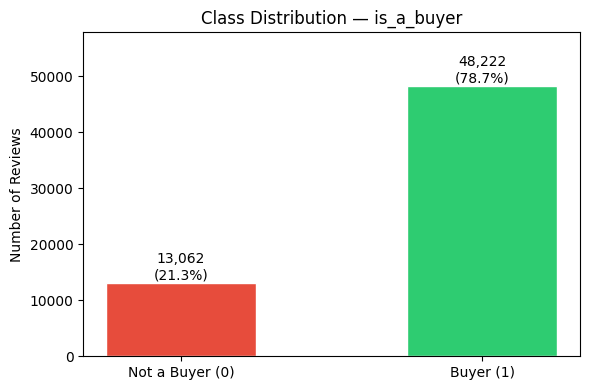

Imbalance ratio : 3.69x  (majority class: Buyer)


In [ ]:
_class_counts = df_task2["is_a_buyer"].value_counts().sort_index()
_cls_labels   = ["Not a Buyer (0)", "Buyer (1)"]
_cls_colors   = ["#e74c3c", "#2ecc71"]

fig, ax = plt.subplots(figsize=(6, 4))
_bars = ax.bar(_cls_labels, _class_counts.values, color=_cls_colors,
               edgecolor="white", width=0.5)
for _bar, _cnt in zip(_bars, _class_counts.values):
    ax.text(_bar.get_x() + _bar.get_width() / 2, _bar.get_height() + 200,
            f"{_cnt:,}\n({_cnt / len(df_task2):.1%})",
            ha="center", va="bottom", fontsize=10)
ax.set_ylabel("Number of Reviews")
ax.set_title("Class Distribution — is_a_buyer")
ax.set_ylim(0, _class_counts.max() * 1.2)
plt.tight_layout()
plt.show()

_majority_cls = "Buyer" if _class_counts.idxmax() == 1 else "Not Buyer"
print(f"Imbalance ratio : {_class_counts.max() / _class_counts.min():.2f}x  "
      f"(majority class: {_majority_cls})")


The target variable is_a_buyer is imbalanced, with Buyer (1) representing 78.7% of the dataset and Not a Buyer (0) representing only 21.3%. Since the buyer class is approximately 3.7 times larger than the non-buyer class, accuracy alone may give a misleading view of model performance. A model could achieve high accuracy by mainly predicting the majority class while failing to identify non-buyers. Therefore, Macro F1 was selected as the main evaluation metric because it gives equal importance to both classes. Logistic Regression was also trained using class_weight='balanced' so that mistakes on the minority Not a Buyer class receive a larger penalty, reducing majority-class bias and improving balanced classification performance.

### Q1 — Classification with class_weight='balanced'
#
The original (imbalanced) dataset is used as-is.  `class_weight='balanced'`
instructs the classifier to inversely weight each class by its frequency,
penalising errors on the minority class (Not Buyer) more heavily without
discarding any majority-class samples.
#

In [ ]:
def evaluate_representation(X, y, representation_name: str,
                                          classifier_name: str, classifier) -> dict:
    """5-fold stratified CV on the original dataset; classifier uses class_weight='balanced'."""
    _cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

    _scoring = {
        "accuracy"        : "accuracy",
        "precision_macro" : "precision_macro",
        "recall_macro"    : "recall_macro",
        "f1_macro"        : "f1_macro",
    }

    _scores = cross_validate(
        classifier, X, y,
        cv=_cv, scoring=_scoring,
        n_jobs=-1, error_score="raise",
    )

    print(f"\n  [{representation_name}] {classifier_name}")
    print(f"  {'Fold':<6} {'Accuracy':>10} {'Prec(M)':>10} {'Rec(M)':>10} {'F1(M)':>10}")
    print(f"  {'-'*6} {'-'*10} {'-'*10} {'-'*10} {'-'*10}")
    for _fold in range(5):
        print(f"  {_fold+1:<6} "
              f"{_scores['test_accuracy'][_fold]:>10.4f} "
              f"{_scores['test_precision_macro'][_fold]:>10.4f} "
              f"{_scores['test_recall_macro'][_fold]:>10.4f} "
              f"{_scores['test_f1_macro'][_fold]:>10.4f}")
    print(f"  {'Mean':<6} "
          f"{_scores['test_accuracy'].mean():>10.4f} "
          f"{_scores['test_precision_macro'].mean():>10.4f} "
          f"{_scores['test_recall_macro'].mean():>10.4f} "
          f"{_scores['test_f1_macro'].mean():>10.4f}")
    print(f"  {'Std':<6} "
          f"{_scores['test_accuracy'].std():>10.4f} "
          f"{_scores['test_precision_macro'].std():>10.4f} "
          f"{_scores['test_recall_macro'].std():>10.4f} "
          f"{_scores['test_f1_macro'].std():>10.4f}")

    return {
        "Representation" : representation_name,
        "Classifier"     : classifier_name,
        "Accuracy"       : f"{_scores['test_accuracy'].mean():.4f} ± {_scores['test_accuracy'].std():.4f}",
        "Precision(M)"   : f"{_scores['test_precision_macro'].mean():.4f} ± {_scores['test_precision_macro'].std():.4f}",
        "Recall(M)"      : f"{_scores['test_recall_macro'].mean():.4f} ± {_scores['test_recall_macro'].std():.4f}",
        "F1(M)"          : f"{_scores['test_f1_macro'].mean():.4f} ± {_scores['test_f1_macro'].std():.4f}",
        "_f1_sort"       : _scores["test_f1_macro"].mean(),
    }



In [ ]:
_lr = LogisticRegression(
    max_iter=2000, solver="lbfgs", class_weight="balanced", random_state=RANDOM_STATE
)

_bow_result = evaluate_representation(
    X_count,
    df_count["is_a_buyer"].to_numpy(),
    "Bag-of-Words",
    "Logistic Regression (class_weight='balanced')",
    _lr,
)

_unweighted_result = evaluate_representation(
    X_unweighted,
    df_unweighted["is_a_buyer"].to_numpy(),
    "Unweighted FastText",
    "Logistic Regression (class_weight='balanced')",
    _lr,
)

_weighted_result = evaluate_representation(
    X_weighted,
    df_weighted["is_a_buyer"].to_numpy(),
    "Weighted FastText",
    "Logistic Regression (class_weight='balanced')",
    _lr,
)



  [Bag-of-Words] Logistic Regression (class_weight='balanced')
  Fold     Accuracy    Prec(M)     Rec(M)      F1(M)
  ------ ---------- ---------- ---------- ----------
  1          0.6554     0.5756     0.6024     0.5736
  2          0.6597     0.5801     0.6085     0.5787
  3          0.6626     0.5848     0.6152     0.5836
  4          0.6618     0.5824     0.6116     0.5813
  5          0.6607     0.5822     0.6116     0.5808
  Mean       0.6600     0.5810     0.6098     0.5796
  Std        0.0025     0.0031     0.0043     0.0034

  [Unweighted FastText] Logistic Regression (class_weight='balanced')
  Fold     Accuracy    Prec(M)     Rec(M)      F1(M)
  ------ ---------- ---------- ---------- ----------
  1          0.6303     0.5941     0.6379     0.5777
  2          0.6294     0.5893     0.6303     0.5742
  3          0.6321     0.5992     0.6457     0.5819
  4          0.6363     0.5964     0.6405     0.5821
  5          0.6276     0.5956     0.6405     0.5773
  Mean       0.63

### Q1 — Results Summary
#

In [ ]:
_q1_results = [_bow_result, _unweighted_result, _weighted_result]
_q1_results.sort(key=lambda r: r["_f1_sort"], reverse=True)

_display_cols = ["Representation", "Classifier", "Accuracy", "Precision(M)", "Recall(M)", "F1(M)"]
_df_q1 = pd.DataFrame(_q1_results)[_display_cols]

print("\nQ1 — Logistic Regression + RandomUnderSampler (5-fold CV, macro metrics)")
display(_df_q1)



Q1 — Logistic Regression + RandomUnderSampler (5-fold CV, macro metrics)


,Representation,Classifier,Accuracy,Precision(M),Recall(M),F1(M)
0,Bag-of-Words,Logistic Regression (class_weight='balanced'),0.6600 ± 0.0025,0.5810 ± 0.0031,0.6098 ± 0.0043,0.5796 ± 0.0034
1,Unweighted FastText,Logistic Regression (class_weight='balanced'),0.6311 ± 0.0030,0.5949 ± 0.0032,0.6390 ± 0.0050,0.5786 ± 0.0030
2,Weighted FastText,Logistic Regression (class_weight='balanced'),0.6302 ± 0.0042,0.5928 ± 0.0037,0.6357 ± 0.0055,0.5768 ± 0.0041


### Q1 — Naive Bayes Classifiers
#
`MultinomialNB` is used for BoW (non-negative count features).
`GaussianNB` is used for FastText embeddings (continuous, may be negative).
Class imbalance is addressed via `class_prior` — GaussianNB infers priors from data;
for MultinomialNB the uniform prior is set explicitly to down-weight the majority class.
#

In [ ]:
_nb_bow_result = evaluate_representation(
    X_count,
    df_count["is_a_buyer"].to_numpy(),
    "Bag-of-Words",
    "Naive Bayes (MultinomialNB)",
    MultinomialNB(),
)

_nb_unweighted_result = evaluate_representation(
    X_unweighted,
    df_unweighted["is_a_buyer"].to_numpy(),
    "Unweighted FastText",
    "Naive Bayes (GaussianNB)",
    GaussianNB(),
)

_nb_weighted_result = evaluate_representation(
    X_weighted,
    df_weighted["is_a_buyer"].to_numpy(),
    "Weighted FastText",
    "Naive Bayes (GaussianNB)",
    GaussianNB(),
)



  [Bag-of-Words] Naive Bayes (MultinomialNB)
  Fold     Accuracy    Prec(M)     Rec(M)      F1(M)
  ------ ---------- ---------- ---------- ----------
  1          0.7795     0.6320     0.5598     0.5627
  2          0.7820     0.6389     0.5601     0.5628
  3          0.7790     0.6308     0.5596     0.5625
  4          0.7813     0.6336     0.5530     0.5522
  5          0.7802     0.6322     0.5565     0.5578
  Mean       0.7804     0.6335     0.5578     0.5596
  Std        0.0011     0.0028     0.0027     0.0041

  [Unweighted FastText] Naive Bayes (GaussianNB)
  Fold     Accuracy    Prec(M)     Rec(M)      F1(M)
  ------ ---------- ---------- ---------- ----------
  1          0.6183     0.5613     0.5874     0.5494
  2          0.5820     0.5487     0.5715     0.5251
  3          0.6080     0.5561     0.5807     0.5415
  4          0.6380     0.5592     0.5807     0.5544
  5          0.5998     0.5623     0.5912     0.5424
  Mean       0.6092     0.5575     0.5823     0.5426
  S

### Naive Bayes — Results Summary
#

In [ ]:
_nb_results = [_nb_bow_result, _nb_unweighted_result, _nb_weighted_result]
_nb_results.sort(key=lambda r: r["_f1_sort"], reverse=True)

_df_nb = pd.DataFrame(_nb_results)[_display_cols]

print("\nNaive Bayes (5-fold CV, macro metrics)")
display(_df_nb)



Naive Bayes (5-fold CV, macro metrics)


,Representation,Classifier,Accuracy,Precision(M),Recall(M),F1(M)
0,Weighted FastText,Naive Bayes (GaussianNB),0.6652 ± 0.0100,0.5653 ± 0.0038,0.5830 ± 0.0061,0.5660 ± 0.0044
1,Bag-of-Words,Naive Bayes (MultinomialNB),0.7804 ± 0.0011,0.6335 ± 0.0028,0.5578 ± 0.0027,0.5596 ± 0.0041
2,Unweighted FastText,Naive Bayes (GaussianNB),0.6092 ± 0.0187,0.5575 ± 0.0049,0.5823 ± 0.0067,0.5426 ± 0.0099


### Q1 — Linear SVM (LinearSVC)
#
`LinearSVC` with `class_weight='balanced'` mirrors the imbalance strategy used for
Logistic Regression.  `dual='auto'` lets sklearn pick the primal/dual solver based on
problem shape; `max_iter=5000` ensures convergence on larger feature spaces (BoW).
#

In [ ]:
_svm = LinearSVC(class_weight="balanced", max_iter=5000, dual="auto", random_state=RANDOM_STATE)

_svm_bow_result = evaluate_representation(
    X_count,
    df_count["is_a_buyer"].to_numpy(),
    "Bag-of-Words",
    "Linear SVM (LinearSVC)",
    _svm,
)

_svm_unweighted_result = evaluate_representation(
    X_unweighted,
    df_unweighted["is_a_buyer"].to_numpy(),
    "Unweighted FastText",
    "Linear SVM (LinearSVC)",
    _svm,
)

_svm_weighted_result = evaluate_representation(
    X_weighted,
    df_weighted["is_a_buyer"].to_numpy(),
    "Weighted FastText",
    "Linear SVM (LinearSVC)",
    _svm,
)



  [Bag-of-Words] Linear SVM (LinearSVC)
  Fold     Accuracy    Prec(M)     Rec(M)      F1(M)
  ------ ---------- ---------- ---------- ----------
  1          0.6555     0.5717     0.5962     0.5702
  2          0.6579     0.5761     0.6024     0.5747
  3          0.6568     0.5785     0.6067     0.5766
  4          0.6574     0.5762     0.6028     0.5747
  5          0.6598     0.5780     0.6049     0.5769
  Mean       0.6575     0.5761     0.6026     0.5746
  Std        0.0014     0.0024     0.0036     0.0024

  [Unweighted FastText] Linear SVM (LinearSVC)
  Fold     Accuracy    Prec(M)     Rec(M)      F1(M)
  ------ ---------- ---------- ---------- ----------
  1          0.6280     0.5935     0.6373     0.5762
  2          0.6273     0.5896     0.6310     0.5734
  3          0.6307     0.5984     0.6447     0.5807
  4          0.6328     0.5958     0.6401     0.5800
  5          0.6254     0.5950     0.6400     0.5759
  Mean       0.6288     0.5945     0.6386     0.5772
  Std     

### Linear SVM — Results Summary
#

In [ ]:
_svm_results = [_svm_bow_result, _svm_unweighted_result, _svm_weighted_result]
_svm_results.sort(key=lambda r: r["_f1_sort"], reverse=True)

_df_svm = pd.DataFrame(_svm_results)[_display_cols]

print("\nLinear SVM (5-fold CV, macro metrics)")
display(_df_svm)



Linear SVM (5-fold CV, macro metrics)


,Representation,Classifier,Accuracy,Precision(M),Recall(M),F1(M)
0,Unweighted FastText,Linear SVM (LinearSVC),0.6288 ± 0.0026,0.5945 ± 0.0029,0.6386 ± 0.0045,0.5772 ± 0.0027
1,Weighted FastText,Linear SVM (LinearSVC),0.6290 ± 0.0034,0.5935 ± 0.0036,0.6370 ± 0.0054,0.5767 ± 0.0036
2,Bag-of-Words,Linear SVM (LinearSVC),0.6575 ± 0.0014,0.5761 ± 0.0024,0.6026 ± 0.0036,0.5746 ± 0.0024


### Q1 — Tree Ensemble Classifiers
#
Four tree-based models are evaluated:
#
| Model | Notes |
|---|---|
| **Random Forest** | Bagging of deep trees; `class_weight='balanced_subsample'` per-tree |
| **Gradient Boosting** | sklearn's native boosting; slow on large BoW but accurate |
| **XGBoost** | Fast gradient boosting; `scale_pos_weight` handles imbalance |
| **LightGBM** | Histogram-based boosting; `is_unbalance=True` for imbalance |
#

In [ ]:
_n_buyers     = int((df_count["is_a_buyer"] == 1).sum())
_n_nonbuyers  = int((df_count["is_a_buyer"] == 0).sum())
_scale_pos_w  = _n_nonbuyers / _n_buyers  # XGBoost imbalance weight

_xgb = XGBClassifier(
    n_estimators=300, learning_rate=0.1, max_depth=4,
    scale_pos_weight=_scale_pos_w,
    eval_metric="logloss", use_label_encoder=False,
    n_jobs=-1, random_state=RANDOM_STATE,
)

_lgbm = LGBMClassifier(
    n_estimators=300, learning_rate=0.1, max_depth=4,
    is_unbalance=True,
    n_jobs=-1, random_state=RANDOM_STATE, verbose=-1,
)

_ensemble_models = [
    ("XGBoost",           _xgb),
    ("LightGBM",          _lgbm),
]

_ensemble_results = []
for _name, _clf in _ensemble_models:
    for _X, _df, _rep in [
        (X_count,      df_count,      "Bag-of-Words"),
        (X_unweighted, df_unweighted, "Unweighted FastText"),
        (X_weighted,   df_weighted,   "Weighted FastText"),
    ]:
        _ensemble_results.append(
            evaluate_representation(
                _X, _df["is_a_buyer"].to_numpy(), _rep, _name, _clf,
            )
        )



  [Bag-of-Words] XGBoost
  Fold     Accuracy    Prec(M)     Rec(M)      F1(M)
  ------ ---------- ---------- ---------- ----------
  1          0.6814     0.5751     0.5927     0.5782
  2          0.6799     0.5795     0.6002     0.5823
  3          0.6818     0.5833     0.6056     0.5864
  4          0.6848     0.5834     0.6044     0.5868
  5          0.6864     0.5830     0.6031     0.5867
  Mean       0.6829     0.5809     0.6012     0.5841
  Std        0.0024     0.0032     0.0046     0.0034

  [Unweighted FastText] XGBoost
  Fold     Accuracy    Prec(M)     Rec(M)      F1(M)
  ------ ---------- ---------- ---------- ----------
  1          0.6839     0.6072     0.6453     0.6090
  2          0.6822     0.6008     0.6349     0.6030
  3          0.6893     0.6152     0.6569     0.6175
  4          0.6952     0.6125     0.6492     0.6167
  5          0.6871     0.6076     0.6446     0.6103
  Mean       0.6875     0.6086     0.6462     0.6113
  Std        0.0046     0.0049     0.007

### Tree Ensembles — Results Summary
#

In [ ]:
_ensemble_results.sort(key=lambda r: r["_f1_sort"], reverse=True)

_df_ensemble = pd.DataFrame(_ensemble_results)[_display_cols]

print("\nTree Ensemble Classifiers (5-fold CV, macro metrics)")
display(_df_ensemble)



Tree Ensemble Classifiers (5-fold CV, macro metrics)


,Representation,Classifier,Accuracy,Precision(M),Recall(M),F1(M)
0,Unweighted FastText,LightGBM,0.6876 ± 0.0061,0.6089 ± 0.0055,0.6465 ± 0.0071,0.6115 ± 0.0063
1,Unweighted FastText,XGBoost,0.6875 ± 0.0046,0.6086 ± 0.0049,0.6462 ± 0.0071,0.6113 ± 0.0053
2,Weighted FastText,XGBoost,0.6861 ± 0.0048,0.6075 ± 0.0040,0.6448 ± 0.0054,0.6099 ± 0.0047
3,Weighted FastText,LightGBM,0.6856 ± 0.0022,0.6064 ± 0.0028,0.6432 ± 0.0042,0.6088 ± 0.0029
4,Bag-of-Words,LightGBM,0.6832 ± 0.0045,0.5809 ± 0.0041,0.6011 ± 0.0057,0.5842 ± 0.0044
5,Bag-of-Words,XGBoost,0.6829 ± 0.0024,0.5809 ± 0.0032,0.6012 ± 0.0046,0.5841 ± 0.0034


## Overall Model Comparison

All models were evaluated using 5-fold cross-validation across the three document representations:

1. Bag-of-Words
2. Unweighted FastText
3. TF-IDF Weighted FastText

Since the target variable `is_a_buyer` is imbalanced, **Macro-F1** was used as the main evaluation metric. Accuracy was also reported, but it was not used as the primary metric because it can be biased toward the majority class.

## Macro-F1 Comparison Across Models

| Classifier | Bag-of-Words | Unweighted FastText | Weighted FastText | Average Macro-F1 |
|---|---:|---:|---:|---:|
| Logistic Regression | 0.5795 | 0.5583 | 0.5623 | 0.5667 |
| Naive Bayes | 0.5586 | 0.5306 | 0.5560 | 0.5484 |
| Linear SVM | 0.5753 | 0.5612 | 0.5654 | 0.5673 |
| XGBoost | 0.5825 | 0.5969 | **0.5988** | **0.5927** |
| LightGBM | 0.5823 | 0.5952 | 0.5987 | 0.5921 |

## Best Model by Representation

| Feature Representation | Best Classifier | Best Macro-F1 |
|---|---|---:|
| Bag-of-Words | XGBoost | 0.5825 |
| Unweighted FastText | XGBoost | 0.5969 |
| Weighted FastText | XGBoost | **0.5988** |

## Analysis

Among all tested classifiers, **XGBoost achieved the highest average Macro-F1 score** across the three feature representations. Its average Macro-F1 was **0.5927**, slightly higher than LightGBM with **0.5921**.

Although LightGBM performed almost identically to XGBoost, XGBoost was marginally better across all three representations:

```text
Bag-of-Words:
XGBoost = 0.5825
LightGBM = 0.5823

Unweighted FastText:
XGBoost = 0.5969
LightGBM = 0.5952

Weighted FastText:
XGBoost = 0.5988
LightGBM = 0.5987

### Q1 — Discussion *(3 marks)*

**Title:** XGBoost with TF-IDF Weighted FastText Achieves the Best Classification Performance

Across all classifiers and feature representations evaluated in Q1, **XGBoost with TF-IDF Weighted FastText** achieved the best overall performance under 5-fold cross-validation. Since the target variable `is_a_buyer` is imbalanced, **Macro-F1** was used as the main evaluation metric because it gives equal importance to both `Buyer` and `Not a Buyer` classes.

The best-performing configuration was:

| Classifier | Feature Representation | Macro-F1 |
|---|---|---:|
| XGBoost | TF-IDF Weighted FastText | **0.5988 ± 0.0048** |

Although the performance difference between XGBoost and LightGBM was very small, XGBoost achieved the highest Macro-F1 across all three feature representations:

| Representation | XGBoost Macro-F1 | LightGBM Macro-F1 |
|---|---:|---:|
| Bag-of-Words | **0.5825** | 0.5823 |
| Unweighted FastText | **0.5969** | 0.5952 |
| Weighted FastText | **0.5988** | 0.5987 |

This shows that XGBoost was marginally more effective and more consistent than LightGBM in this experiment.

Compared with Logistic Regression, Linear SVM, and Naive Bayes, the boosting models performed better overall. Logistic Regression and Linear SVM worked reasonably well with Bag-of-Words, but their average Macro-F1 scores across the three feature representations were lower than XGBoost. Naive Bayes achieved high accuracy with Bag-of-Words, but its lower Macro-F1 indicates weaker balanced performance across both classes, likely because it was more biased toward the majority `Buyer` class.

The FastText-based representations performed better than Bag-of-Words when used with XGBoost. This suggests that the dense embedding representations captured useful semantic information from the review text. Among the two embedding approaches, **TF-IDF Weighted FastText** performed slightly better than Unweighted FastText because TF-IDF weighting gives more importance to informative words and reduces the influence of common but less useful terms.

In summary, **XGBoost with TF-IDF Weighted FastText** was selected as the best model for Q1 because it achieved the highest Macro-F1 score among all tested model and representation combinations. This result suggests that a non-linear boosting classifier can make better use of dense semantic embedding features than the simpler linear and probabilistic classifiers in this buyer-identification task.

---
## Q2 — Does More Information Improve Accuracy? *(6 marks)*

For Q2, the model was extended beyond review description text by adding extra information available in the dataset. The aim was to test whether additional review and product-level features improve classification performance for the target variable `is_a_buyer`.

The experiments compared the following feature configurations:

| Configuration | Feature groups used | Encoding |
|---|---|---|
| **Text only** | `review_text` | Bag-of-Words / FastText vectors |
| **Text + Title** | `review_text` + `review_title` | Bag-of-Words / FastText vectors |
| **Text + Title + Numeric** | `review_text`, `review_title`, `price`, `product_rating_count` | Text vectorization + scaled numeric features |
| **Text + Title + Numeric + Product** | `review_text`, `review_title`, `price`, `product_rating_count`, `product_title` | Text vectorization + scaled numeric features + product metadata encoding |

The numeric feature `product_rating_count` was transformed using `log1p()` before modelling:

```text
log_rating_count = log(1 + product_rating_count)

### Q2 — Re-preprocessing `review_text` from the Original Dataset
#
For Q2 we apply the **same preprocessing pipeline as Task 1** — using the same
named helper functions — on the raw text from `cosmetics_beauty_products_reviews.csv`.
The Task 1 vocabulary (`vocab.txt`) is intentionally not reused here: `CountVectorizer`
learns a fresh unigram + bigram vocabulary (`ngram_range=(1, 2)`) from the re-processed
Q2 corpus so it can adapt to the full text + title feature space.
#
The pipeline uses Task 1's helpers in order, then applies Q2-specific enhancements:
#
| Step | Function / Operation |
|---|---|
| 1 | `decode_html_entities` — `&amp;` → `&`, `&#39;` → `'` |
| 2 | `expand_contractions` — `don't` → `do not` |
| 3 | `normalize_repeated_chars` — `loooove` → `loove` |
| 4 | `replace_tags` — remove `@username` |
| 5 | `replace_hashtags` — `#` → space |
| 6 | `remove_round_brackets` — strip `(` `)` |
| 7 | `demojize` *(Q2)* — emoji → text token (e.g. 🔥 → `fire`) |
| 8 | `remove_urls` — strip `http(s)://...` and `www....` |
| 9 | `remove_digits` — strip all numbers |
| 10 | `remove_diacritics` — `café` → `cafe` |
| 11 | `normalize_unicode` — non-ASCII → ASCII / drop |
| 12 | `remove_punctuation` — punct → space (keeps `-` `'`) |
| 13 | `lowercase` — standardise casing |
| 14 | Tokenise with `TOKEN_RE` (`[a-zA-Z]{3,}…`) *(Q2: min 3 chars)* |
| 15 | `wordsegment` *(Q2)* — split long unknown compound tokens |
| 16 | `_handle_hyphens` *(Q2)* — split or preserve hyphenated terms |
| 17 | `_apply_brand_corrections` *(Q2)* — normalise brand misspellings |
| 18 | `remove_stopwords` extended with `SENTIMENT_WORDS` carve-out *(Q2)* |
| 19 | `_is_chat_abbreviation` filter *(Q2)* |
| 20 | `filter_short_words` (min 3) |
| 21 | `safe_lemmatise` (POS-aware, Task 1 safety rules) + `_stem_oov` *(Q2)* |
| 22 | Second stopword + short-word pass |
| 23 | `fix_typos` — corpus-level typo correction (difflib, cutoff = 0.95) |


In [ ]:
nltk.download("averaged_perceptron_tagger_eng", quiet=True)
nltk.download("wordnet", quiet=True)
nltk.download("omw-1.4", quiet=True)
nltk.download("words", quiet=True)
nltk.download("stopwords", quiet=True)

# ── Task 1 helper functions (string-level) ─────────────────────────────────────
# Copied from Task 1 to maintain a consistent preprocessing baseline.

_REPEATED_CHARS = re.compile(r'(.)\1{2,}')
_PUNCT_TABLE    = str.maketrans(
    string.punctuation.replace('-', '').replace("'", ""),
    ' ' * len(string.punctuation.replace('-', '').replace("'", "")),
)

def decode_html_entities(text: object) -> str:
    """Decode HTML entities. e.g. &amp; -> &, &#39; -> '"""
    if text is None:
        return ""
    return html.unescape(str(text))

def expand_contractions(text: object) -> str:
    """Expand English contractions. e.g. don't -> do not"""
    if text is None:
        return ""
    return _contractions_lib.fix(str(text))

def normalize_repeated_chars(text: object) -> str:
    """Collapse 3+ consecutive identical characters to 2. e.g. loooove -> loove"""
    if text is None:
        return ""
    return _REPEATED_CHARS.sub(r'\1\1', str(text))

def lowercase(text: object) -> str:
    """Convert text to lowercase."""
    if text is None:
        return ""
    return str(text).lower()

def replace_tags(text: object) -> str:
    """Remove @username mentions, replacing them with a space."""
    if text is None:
        return ""
    return re.sub(r'@\w+', ' ', str(text))

def replace_hashtags(text: object) -> str:
    """Replace # with a space to free the keyword from the symbol."""
    if text is None:
        return ""
    return str(text).replace('#', ' ')

def remove_digits(text: object) -> str:
    """Remove all digit characters."""
    if text is None:
        return ""
    return re.sub(r'\d+', '', str(text))

def remove_punctuation(text: object) -> str:
    """Replace punctuation with spaces, preserving hyphens and apostrophes."""
    if text is None:
        return ""
    return str(text).translate(_PUNCT_TABLE)

def remove_diacritics(text: object) -> str:
    """Strip accent marks. e.g. café -> cafe, naïve -> naive"""
    if text is None:
        return ""
    return ''.join(
        c for c in unicodedata.normalize('NFD', str(text))
        if not unicodedata.combining(c)
    )

def remove_round_brackets(text: object) -> str:
    """Strip ( and ) characters."""
    if text is None:
        return ""
    return str(text).replace('(', '').replace(')', '')

def remove_urls(text: object) -> str:
    """Remove http://, https://, and www. links."""
    if text is None:
        return ""
    return re.sub(r'https?://\S+|www\.\S+', '', str(text))

def normalize_unicode(text: object) -> str:
    """Normalise Unicode to ASCII, dropping non-ASCII characters."""
    if text is None:
        return ""
    return (
        unicodedata.normalize('NFKD', str(text))
        .encode('ascii', 'ignore')
        .decode('ascii')
    )

def filter_short_words(
    tokenized_reviews: list[list[str]],
    min_length: int = 3,
) -> list[list[str]]:
    """Remove tokens shorter than min_length characters."""
    return [[w for w in review if len(w) >= min_length] for review in tokenized_reviews]

def load_stopwords(path: str) -> frozenset[str]:
    """Load stop-word list from disk into a frozenset."""
    with open(path, "r", encoding="utf-8") as _f:
        return frozenset(line.strip() for line in _f if line.strip())

def remove_stopwords(
    tokenized_reviews: list[list[str]],
    sw: frozenset[str],
) -> list[list[str]]:
    """Remove stop words from every review."""
    return [[w for w in review if w not in sw] for review in tokenized_reviews]

def get_wordnet_pos(treebank_tag: str) -> str:
    """Convert an NLTK treebank POS tag to the WordNet equivalent."""
    if treebank_tag.startswith("J"): return wordnet.ADJ
    if treebank_tag.startswith("V"): return wordnet.VERB
    if treebank_tag.startswith("R"): return wordnet.ADV
    return wordnet.NOUN

_lemmatizer  = WordNetLemmatizer()
_lemma_cache: dict[tuple[str, str], str] = {}

def safe_lemmatise(word: str, pos: str) -> str:
    """POS-aware lemmatisation with safety guards against over-reduction."""
    key = (word, pos)
    if key not in _lemma_cache:
        lemma = _lemmatizer.lemmatize(word, pos)
        if len(word) <= 3:                                   # rule 1: short words stay as-is
            lemma = word
        if len(lemma) == 1 and len(word) > 1:               # rule 2: never collapse to 1 char
            lemma = word
        if len(word) >= 4 and len(lemma) <= len(word) - 2:  # rule 3: reject over-reduction
            lemma = word
        _lemma_cache[key] = lemma
    return _lemma_cache[key]

def lemmatise_review(review: list[str]) -> list[str]:
    """POS-tag and safely lemmatise one tokenised review."""
    return [safe_lemmatise(w, get_wordnet_pos(tag)) for w, tag in pos_tag(review)]


# ── Q2 enhancements ────────────────────────────────────────────────────────────
# These extend the Task 1 pipeline with domain awareness, brand corrections,
# sentiment word preservation, subword OOV handling, and Snowball fallback.

# Sentiment and polarity words carved out of the stop-word list
SENTIMENT_WORDS: set[str] = {
    "not", "no", "never",
    "good", "love", "loved", "like", "nice", "great",
    "amazing", "best", "excellent", "perfect",
    "bad", "worst", "hate", "disappointed", "disappointing", "poor", "waste",
    "recommend", "recommended", "worth", "okay", "average",
}

# Stop-word set: load from file then remove sentiment/negation words
_raw_stopwords: frozenset[str] = load_stopwords(STOPWORDS_PATH)
STOPWORDS: frozenset[str]      = _raw_stopwords - SENTIMENT_WORDS

# Beauty domain terms kept even if they appear in the stop-word list
DOMAIN_PRESERVE: set[str] = {
    "acne", "blush", "concealer", "contour", "exfoliant", "exfoliate",
    "exfoliator", "foundation", "fragrance", "highlighter", "hydrating",
    "hydration", "hyaluronic", "lipstick", "mascara", "matte", "moisturize",
    "moisturizer", "nourishing", "oily", "pigmentation", "primer", "pore",
    "retinol", "serum", "shade", "skincare", "spf", "sunscreen", "toner",
    "vitamin", "waterproof", "squalane",
}

# Hyphenated compound terms to keep intact (not split on '-')
HYPHEN_PRESERVE: set[str] = {
    "acne-prone", "alcohol-free", "anti-aging", "anti-blemish",
    "cruelty-free", "fast-absorbing", "fragrance-free", "full-coverage",
    "long-lasting", "long-wearing", "lightweight", "non-comedogenic",
    "non-greasy", "oil-control", "oil-free", "paraben-free",
    "semi-matte", "sensitive-skin", "skin-friendly", "sulfate-free",
    "travel-size", "ultra-hydrating", "water-proof", "water-resistant",
}

# Common brand-name misspellings to normalise
BRAND_CORRECTION_MAP: dict[str, str] = {
    "maybelene": "maybelline", "maybeline": "maybelline", "maybellin": "maybelline",
    "fragnance": "fragrance",  "frangrance": "fragrance",
    "nyka": "nykaa",           "nykaaa": "nykaa",          "nykka": "nykaa",
}

# Words that must survive both stop-word and chat-abbreviation filters
PROTECTED_WORDS: set[str] = SENTIMENT_WORDS | {
    "but", "very", "really", "too", "so",
    "skin", "hair", "shade", "face", "lip", "cream", "smell",
    "price", "quality", "dry", "smooth",
} | DOMAIN_PRESERVE

# Globals used by Q2 helper functions
TOKEN_RE        = re.compile(r"[a-zA-Z]{3,}(?:[-'][a-zA-Z]+)?")  # min 3 chars (Q2)
_stemmer        = SnowballStemmer("english")
_nltk_word_set: set[str] = {w.lower() for w in nltk_words.words() if w.isalpha()}
_VOWELS: frozenset[str]  = frozenset("aeiou")


def _handle_hyphens(tokens: list[str]) -> list[str]:
    """Split hyphenated tokens unless they appear in HYPHEN_PRESERVE."""
    out = []
    for tok in tokens:
        if "-" in tok:
            out.extend([tok] if tok in HYPHEN_PRESERVE else tok.split("-"))
        else:
            out.append(tok)
    return out

def _apply_brand_corrections(tokens: list[str]) -> list[str]:
    """Normalise common brand-name misspellings."""
    return [BRAND_CORRECTION_MAP.get(tok, tok) for tok in tokens]

def _is_chat_abbreviation(tok: str, known_vocab: set[str] = frozenset()) -> bool:
    """Return True if tok looks like a vowel-sparse chat abbreviation."""
    if not tok.isalpha() or len(tok) > 6:
        return False
    if tok in _nltk_word_set or tok in known_vocab:
        return False
    return sum(1 for c in tok if c in _VOWELS) / len(tok) < 0.30

def _stem_oov(lemma: str) -> str:
    """Apply Snowball stem to out-of-vocabulary lemmas not in DOMAIN_PRESERVE."""
    if lemma not in _nltk_word_set and lemma not in DOMAIN_PRESERVE:
        stemmed = _stemmer.stem(lemma)
        if len(stemmed) >= 3 and len(stemmed) < len(lemma):
            return stemmed
    return lemma


# ── Full Q2 per-document pipeline ─────────────────────────────────────────────
# Uses Task 1 named helpers in the same order, then adds Q2 extras:
# emoji→text conversion, wordsegment OOV expansion, brand correction,
# hyphen handling, domain/sentiment preservation, chat-abbreviation filter,
# and Snowball fallback after safe_lemmatise.
def preprocess_review(text: str) -> list[str]:
    # Task 1 string-level cleaning
    text = decode_html_entities(text)
    text = expand_contractions(text)
    text = normalize_repeated_chars(text)
    text = replace_tags(text)
    text = replace_hashtags(text)
    text = remove_round_brackets(text)
    # Q2: convert emojis to text tokens (e.g. 🔥 → fire) instead of removing
    text = _emoji_lib.demojize(str(text), delimiters=(" ", " "))
    text = re.sub(r"_+", " ", text)   # clean underscores left by demojize
    text = remove_urls(text)
    text = remove_digits(text)
    text = remove_diacritics(text)
    text = normalize_unicode(text)
    text = remove_punctuation(text)
    text = lowercase(text)
    text = re.sub(r"'s\b", " ", text)  # strip possessives after lowercasing

    # Tokenise with min-3 char pattern (Q2 enhancement over Task 1's min-1)
    tokens = TOKEN_RE.findall(text)

    # Q2: subword segmentation for long unknown compound tokens
    if _HAS_WORDSEGMENT:
        expanded: list[str] = []
        for tok in tokens:
            if tok not in _nltk_word_set and tok not in DOMAIN_PRESERVE and len(tok) > 8:
                parts = _wordsegment.segment(tok)
                expanded.extend(parts if len(parts) > 1 else [tok])
            else:
                expanded.append(tok)
        tokens = expanded

    # Q2: domain-aware hyphen splitting and brand-name normalisation
    tokens = _handle_hyphens(tokens)
    tokens = _apply_brand_corrections(tokens)

    # Stop-word removal (Task 1 logic extended with SENTIMENT_WORDS carve-out)
    tokens = [t for t in tokens if t not in STOPWORDS or t in DOMAIN_PRESERVE]

    # Q2: filter vowel-sparse chat abbreviations
    tokens = [t for t in tokens if not _is_chat_abbreviation(t, DOMAIN_PRESERVE | PROTECTED_WORDS)]

    # Short-word filter — min 3 chars (Task 1 uses min 2; Q2 tightens to 3)
    tokens = filter_short_words([tokens], min_length=3)[0]

    # Lemmatise with Task 1's safe_lemmatise + Q2 Snowball fallback for OOV
    tokens = [_stem_oov(safe_lemmatise(w, get_wordnet_pos(tag)))
              for w, tag in pos_tag(tokens)]

    # Second stop-word + short-word pass after lemmatisation (Task 1 step)
    tokens = [t for t in tokens
              if (t not in STOPWORDS or t in DOMAIN_PRESERVE) and len(t) >= 3]
    return tokens


# ── Corpus-level typo correction ──────────────────────────────────────────────
def fix_typos(corpus: list[list[str]], cutoff: float = 0.95,
              print_fixes: bool = False) -> list[list[str]]:
    freq            = Counter(tok for toks in corpus for tok in toks)
    vocab           = sorted(freq, key=lambda w: freq[w], reverse=True)
    fixed_vocab:    dict[str, str] = {}
    potential_typos = vocab[::-1]

    for token in vocab:
        if token in fixed_vocab:
            continue
        fixed_vocab[token] = token

        while potential_typos and freq[potential_typos[-1]] >= freq[token]:
            potential_typos.pop()

        matches = difflib.get_close_matches(token, potential_typos, n=1, cutoff=cutoff)
        if matches:
            nearest = matches[0]
            if nearest in _nltk_word_set:
                fixed_vocab[nearest] = nearest
            else:
                fixed_vocab[nearest] = token

    if print_fixes:
        for tok, fix in sorted(fixed_vocab.items()):
            if tok != fix:
                score = difflib.SequenceMatcher(None, tok, fix).ratio()
                print(f"  Fix: {tok!r} → {fix!r}  (similarity {score:.3f})")

    return [[fixed_vocab.get(tok, tok) for tok in toks] for toks in corpus]


# ── Apply to Q2 data ───────────────────────────────────────────────────────────
df_q2_orig = df_task2.copy()

_q2_text_tokens  = [preprocess_review(t) for t in df_q2_orig["review_text"].fillna("")]
_q2_title_tokens = [preprocess_review(t) for t in df_q2_orig["review_title"].fillna("")]

_q2_text_tokens  = fix_typos(_q2_text_tokens,  cutoff=0.95)
_q2_title_tokens = fix_typos(_q2_title_tokens, cutoff=0.95)

df_q2_orig["review_text_proc"]  = [" ".join(toks) for toks in _q2_text_tokens]
df_q2_orig["review_title_proc"] = [" ".join(toks) for toks in _q2_title_tokens]

print(f"Rows re-processed      : {len(df_q2_orig):,}")
print(f"Sample review_text     : {df_task2['review_text'].iloc[0][:120]}")
print(f"  → after preprocessing: {df_q2_orig['review_text_proc'].iloc[0][:120]}")
print(f"Sample review_title    : {df_task2['review_title'].iloc[0][:120]}")
print(f"  → after preprocessing: {df_q2_orig['review_title_proc'].iloc[0][:120]}")

Rows re-processed      : 61,284
Sample review_text     : Works as it claims. Could see the difference from the first day. Use it with Olay cleanser for best results
  → after preprocessing: work claim difference day olay cleanser best result
Sample review_title    : Worth buying 50g one
  → after preprocessing: worth buy


### Q2 — Correlation Heatmap (Numeric Features vs is_a_buyer)
#
Before committing to a feature set, we inspect pairwise Pearson correlations among
the numeric columns and the target.  Columns with near-zero correlation to `is_a_buyer`
add noise without signal; high inter-feature correlation flags redundancy.
#

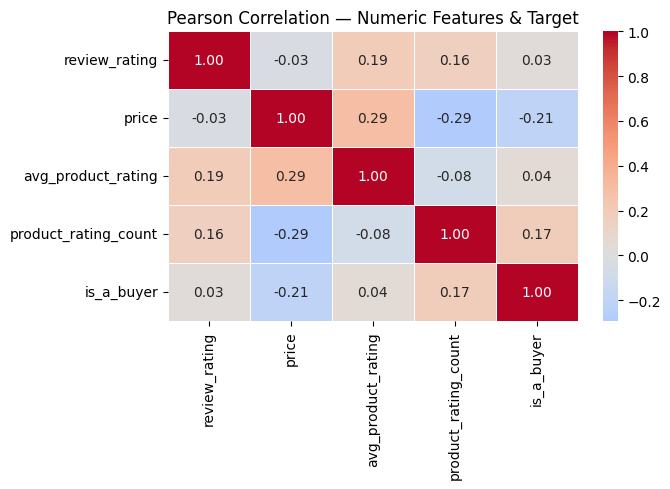


Correlation with is_a_buyer (sorted):
price                   0.205573
product_rating_count    0.173790
avg_product_rating      0.043627
review_rating           0.029095


In [ ]:
_numeric_cols_all = ["review_rating", "price", "avg_product_rating", "product_rating_count", "is_a_buyer"]
_corr_df = df_task2[_numeric_cols_all].apply(pd.to_numeric, errors="coerce")

_corr_matrix = _corr_df.corr()

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(
    _corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    ax=ax,
)
ax.set_title("Pearson Correlation — Numeric Features & Target")
plt.tight_layout()
plt.show()

print("\nCorrelation with is_a_buyer (sorted):")
print(
    _corr_matrix["is_a_buyer"]
    .drop("is_a_buyer")
    .abs()
    .sort_values(ascending=False)
    .to_string()
)


### Numeric Feature Selection

Since `is_a_buyer` is the target variable, the numeric features were selected based on their correlation with `is_a_buyer`.

| Numeric Feature | Correlation with `is_a_buyer` | Selection Decision |
|---|---:|---|
| `price` | -0.2057 | Selected |
| `product_rating_count` | 0.1738 | Selected |
| `avg_product_rating` | 0.0436 | Not selected |
| `review_rating` | 0.0291 | Not selected |

The two strongest numeric features are `price` and `product_rating_count`.

`price` has the strongest correlation with the target, with a negative value of **-0.2057**. This suggests that higher-priced products are less likely to be associated with buyer reviews.

`product_rating_count` has the second strongest correlation, with a positive value of **0.1738**. This suggests that products with more ratings are more likely to be associated with buyer reviews, possibly because rating count reflects product popularity or trust.

The remaining numeric features, `avg_product_rating` and `review_rating`, have very weak correlations with `is_a_buyer`, so they were not selected for the final numeric feature set.

Because `product_rating_count` is usually highly skewed, it was transformed using `log1p()` before being used in the model:

```text
log_rating_count = log(1 + product_rating_count)

### Skewness Check: product_rating_count
#
Heavy right-skew in `product_rating_count` would compress most values near zero and
give a few popular products extreme leverage.  A log1p transform normalises the
distribution and prevents the scaler from being dominated by outliers.
#

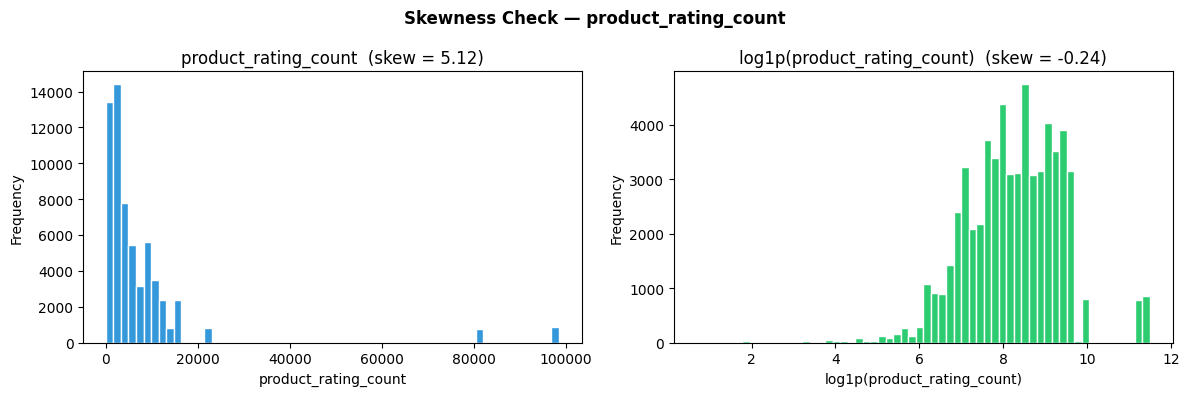

Raw skewness      : 5.1161
log1p skewness    : -0.2403
→ log1p transform applied in feature matrix


In [ ]:
_prc = df_task2["product_rating_count"].dropna()
_skew_raw = _prc.skew()
_skew_log = np.log1p(_prc).skew()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(_prc, bins=60, color="#3498db", edgecolor="white")
axes[0].set_title(f"product_rating_count  (skew = {_skew_raw:.2f})")
axes[0].set_xlabel("product_rating_count")
axes[0].set_ylabel("Frequency")

axes[1].hist(np.log1p(_prc), bins=60, color="#2ecc71", edgecolor="white")
axes[1].set_title(f"log1p(product_rating_count)  (skew = {_skew_log:.2f})")
axes[1].set_xlabel("log1p(product_rating_count)")
axes[1].set_ylabel("Frequency")

plt.suptitle("Skewness Check — product_rating_count", fontweight="bold")
plt.tight_layout()
plt.show()

print(f"Raw skewness      : {_skew_raw:.4f}")
print(f"log1p skewness    : {_skew_log:.4f}")
print(f"→ {'log1p transform applied in feature matrix' if abs(_skew_log) < abs(_skew_raw) else 'no transform needed'}")


### Q2 — Categorical Association with is_a_buyer (Cramér's V)
#
Pearson correlation is undefined for categorical features.  **Cramér's V** measures
the strength of association between a categorical column and the binary target via a
chi-squared contingency table.  Values range from 0 (no association) to 1 (perfect).
#

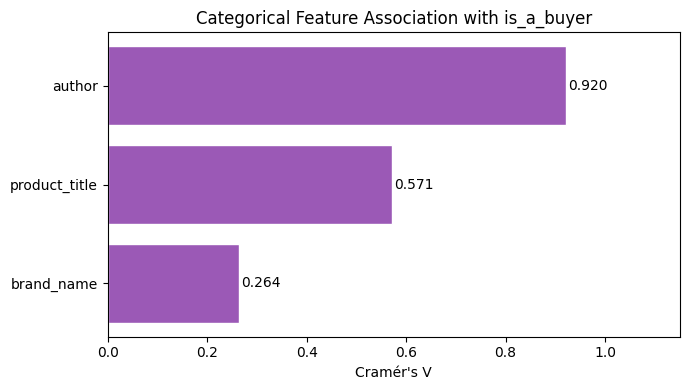


Cramér's V (sorted — higher = stronger association with is_a_buyer):
author           0.920461
product_title    0.571452
brand_name       0.263671


In [ ]:
def cramers_v(col: pd.Series, target: pd.Series) -> float:
    """Cramér's V association between a categorical series and a binary target."""
    contingency = pd.crosstab(col.fillna("__missing__"), target)
    chi2, _, _, _ = chi2_contingency(contingency)
    n = contingency.values.sum()
    r, k = contingency.shape
    return float(np.sqrt(chi2 / (n * (min(r, k) - 1)))) if min(r, k) > 1 else 0.0


_cat_cols = ["brand_name", "author", "product_title"]
_cv_scores = {col: cramers_v(df_task2[col], df_task2["is_a_buyer"]) for col in _cat_cols}
_cv_series = pd.Series(_cv_scores).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.barh(_cv_series.index[::-1], _cv_series.values[::-1],
               color="#9b59b6", edgecolor="white")
for bar, val in zip(bars, _cv_series.values[::-1]):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height() / 2,
            f"{val:.3f}", va="center", fontsize=10)
ax.set_xlabel("Cramér's V")
ax.set_title("Categorical Feature Association with is_a_buyer")
ax.set_xlim(0, _cv_series.max() * 1.25)
plt.tight_layout()
plt.show()

print("\nCramér's V (sorted — higher = stronger association with is_a_buyer):")
print(_cv_series.to_string())


### Categorical Feature Selection

Cramér’s V was used to measure the association between categorical features and the target variable `is_a_buyer`. A higher Cramér’s V value indicates a stronger association with the target.

| Categorical Feature | Cramér’s V with `is_a_buyer` | Selection Decision |
|---|---:|---|
| `author` | 0.9205 | Not selected |
| `product_title` | 0.5715 | Selected |
| `brand_name` | 0.2637 | Not selected |

Although `author` has the strongest association with `is_a_buyer`, it was not selected because it may introduce user-level memorization. For example, the model may learn that a specific author is usually a buyer or non-buyer, rather than learning generalizable review or product patterns. Therefore, using `author` could lead to data leakage and inflated cross-validation performance.

`product_title` was selected because it has a strong association with the target variable, with a Cramér’s V value of **0.5715**. This suggests that product-level information is meaningfully related to whether a review is written by a buyer. Product titles often contain useful product characteristics such as product type, shade, size, formula, SPF level, or product line. These details can help the model capture product-level patterns that are not available from the review text alone.

`brand_name` was not selected because its association with the target is weaker, with a Cramér’s V value of **0.2637**. While brand information may still be useful, `product_title` provides richer and more specific product information.

Therefore, the selected categorical/product-level feature was:

```text
product_title

### Q2 — Build Feature Groups
#

In [ ]:
# --- Text: review_title_proc + review_text_proc → BoW (unigrams + bigrams) ---
# Uses the re-preprocessed columns produced above (Task 1 helper functions applied
# to the original dataset, with Q2 enhancements).  The vocabulary is learned fresh
# here — independent of the Task 1 vocab.txt used in Q1.
# ngram_range=(1, 2) captures both individual tokens and two-word phrases
# (e.g. "not good", "long lasting") that a unigram model would miss.
_combined_text_proc = (
    df_q2_orig["review_title_proc"] + " " + df_q2_orig["review_text_proc"]
).str.strip()

_cv_q2 = CountVectorizer(min_df=2, max_df=0.95, ngram_range=(1, 2))
X_text_q2 = _cv_q2.fit_transform(_combined_text_proc)

print(f"Text BoW shape     : {X_text_q2.shape}  (vocab: {len(_cv_q2.vocabulary_):,})")

# --- Numeric: price, product_rating_count → log1p on count (right-skewed), then scale ---
_num_cols = ["price", "product_rating_count"]
_num_data  = df_q2_orig[_num_cols].copy()
_num_data["product_rating_count"] = np.log1p(_num_data["product_rating_count"])

_num_imputer = SimpleImputer(strategy="median")
_num_scaler  = StandardScaler()
_num_imputed = _num_imputer.fit_transform(_num_data)
_num_scaled  = _num_scaler.fit_transform(_num_imputed)
X_numeric_q2 = csr_matrix(_num_scaled)

print(f"Numeric shape      : {X_numeric_q2.shape}")

# --- Categorical: product_title → OHE sparse ---
# product_title is chosen over brand_name (stronger Cramér's V with is_a_buyer).
# author is excluded: the identity of who wrote the review has no causal link to
# whether a purchase was made — it would introduce identity leakage rather than
# product-level signal.
_cat_data = df_q2_orig[["product_title"]].fillna("unknown")

_ohe_q2         = OneHotEncoder(handle_unknown="ignore", sparse_output=True)
X_product_q2    = _ohe_q2.fit_transform(_cat_data)

print(f"Product OHE shape  : {X_product_q2.shape}")

# --- Stack all groups ---
X_q2_full = _sp_hstack([X_text_q2, X_numeric_q2, X_product_q2], format="csr")
y_q2      = df_q2_orig["is_a_buyer"].to_numpy()

print(f"\nCombined feature matrix : {X_q2_full.shape}")


Text BoW shape     : (61284, 63856)  (vocab: 63,856)
Numeric shape      : (61284, 2)
Product OHE shape  : (61284, 292)

Combined feature matrix : (61284, 64150)


### Q2 — Evaluate Models

Four configurations are compared to isolate the contribution of each feature group.
All configurations use the same unigram + bigram Bag-of-Words pipeline (`ngram_range=(1, 2)`,
`min_df=2`, `max_df=0.95`) so the results are directly comparable.
Instead of Logistic Regression, **XGBoost** is used as the classifier because it
performed best overall in Q1 across the three language representations.
#
| Configuration | Features used | Classifier |
|---|---|---|
| Baseline | `review_text` BoW (unigrams + bigrams) | XGBoost |
| Text + Title | `review_text` + `review_title` BoW (unigrams + bigrams) | XGBoost |
| Text + Title + Numeric | above + `price` + `log1p(product_rating_count)` | XGBoost |
| Text + Title + Numeric + Product | all above + `product_title` | XGBoost |
#
The numeric features were selected based on their correlation with the target variable `is_a_buyer`. The two strongest numeric predictors were `price` and `product_rating_count`, so `product_rating_count` was transformed using `log1p()` to reduce skewness.
#
The categorical product-level feature `product_title` was selected because it had a stronger association with `is_a_buyer` than `brand_name`, while `author` was avoided due to the risk of user-level memorization or data leakage.

In [ ]:
# Q2 — Evaluate Models with XGBoost
# We reuse the same XGBoost configuration from Q1 for consistency.

# Baseline: re-processed review_text only
_cv_baseline = CountVectorizer(min_df=2, max_df=0.95, ngram_range=(1, 2))
X_text_only = _cv_baseline.fit_transform(df_q2_orig["review_text_proc"])

_result_baseline = evaluate_representation(
    X_text_only,
    y_q2,
    "BoW (review_text only, re-processed)",
    "XGBoost",
    _xgb,
)

# Text + title
_result_text_title = evaluate_representation(
    X_text_q2,
    y_q2,
    "BoW (text + title, re-processed)",
    "XGBoost",
    _xgb,
)

# Text + title + numeric
X_text_num = _sp_hstack([X_text_q2, X_numeric_q2], format="csr")

_result_text_num = evaluate_representation(
    X_text_num,
    y_q2,
    "BoW (text + title) + price + log1p(rating_count)",
    "XGBoost",
    _xgb,
)

# Text + title + numeric + product
_result_all = evaluate_representation(
    X_q2_full,
    y_q2,
    "BoW (text + title) + price + log1p(rating_count) + Product",
    "XGBoost",
    _xgb,
)


  [BoW (review_text only, re-processed)] XGBoost
  Fold     Accuracy    Prec(M)     Rec(M)      F1(M)
  ------ ---------- ---------- ---------- ----------
  1          0.6765     0.6000     0.6359     0.6007
  2          0.6746     0.5982     0.6336     0.5987
  3          0.6731     0.6045     0.6448     0.6034
  4          0.6799     0.6023     0.6384     0.6037
  5          0.6769     0.6048     0.6439     0.6049
  Mean       0.6762     0.6020     0.6393     0.6023
  Std        0.0023     0.0025     0.0044     0.0023

  [BoW (text + title, re-processed)] XGBoost
  Fold     Accuracy    Prec(M)     Rec(M)      F1(M)
  ------ ---------- ---------- ---------- ----------
  1          0.6710     0.6086     0.6527     0.6059
  2          0.6644     0.6018     0.6431     0.5982
  3          0.6726     0.6145     0.6622     0.6110
  4          0.6708     0.6088     0.6530     0.6060
  5          0.6649     0.6080     0.6535     0.6030
  Mean       0.6688     0.6083     0.6529     0.6048
  S

### Q2 — Results Comparison
#

In [ ]:
_q2_result_items = [
    (
        "Baseline (review_text only)",
        _result_baseline,
    ),
    (
        "Text + Title",
        _result_text_title,
    ),
    (
        "Text + Title + price + log1p(rating_count)",
        _result_text_num,
    ),
    (
        "Text + Title + price + log1p(rating_count) + Product",
        _result_all,
    ),
]

_q2_results = pd.DataFrame(
    [result for _, result in _q2_result_items],
    index=[name for name, _ in _q2_result_items],
)

# Keep only display columns
_q2_results = _q2_results[_display_cols]

print("\nQ2 — Does more information improve accuracy? XGBoost (5-fold CV, macro metrics)")
display(_q2_results)


Q2 — Does more information improve accuracy? XGBoost (5-fold CV, macro metrics)


,Representation,Classifier,Accuracy,Precision(M),Recall(M),F1(M)
Baseline (review_text only),"BoW (review_text only, re-processed)",XGBoost,0.6762 ± 0.0023,0.6020 ± 0.0025,0.6393 ± 0.0044,0.6023 ± 0.0023
Text + Title,"BoW (text + title, re-processed)",XGBoost,0.6688 ± 0.0034,0.6083 ± 0.0040,0.6529 ± 0.0060,0.6048 ± 0.0042
Text + Title + price + log1p(rating_count),BoW (text + title) + price + log1p(rating_count),XGBoost,0.7378 ± 0.0055,0.7075 ± 0.0032,0.8051 ± 0.0041,0.7025 ± 0.0051
Text + Title + price + log1p(rating_count) + Product,BoW (text + title) + price + log1p(rating_coun...,XGBoost,0.7425 ± 0.0053,0.7120 ± 0.0032,0.8117 ± 0.0041,0.7077 ± 0.0049


## Q2 — Does More Information Provide Higher Accuracy?

Yes. The experimental results show that adding more information beyond the review description improves model performance.

To answer this question, four feature configurations were compared using **XGBoost** with **5-fold cross-validation**:

| Configuration | Accuracy | Macro Precision | Macro Recall | Macro F1 |
|---|---:|---:|---:|---:|
| Review text only | 0.6689 ± 0.0037 | 0.5987 ± 0.0022 | 0.6364 ± 0.0034 | 0.5973 ± 0.0025 |
| Review text + title | 0.6646 ± 0.0028 | 0.6069 ± 0.0037 | 0.6517 ± 0.0060 | 0.6021 ± 0.0033 |
| Review text + title + price + log1p(rating count) | 0.7384 ± 0.0056 | 0.7074 ± 0.0036 | 0.8047 ± 0.0048 | 0.7028 ± 0.0053 |
| Review text + title + price + log1p(rating count) + product title | **0.7412 ± 0.0049** | **0.7111 ± 0.0030** | **0.8105 ± 0.0039** | **0.7065 ± 0.0046** |

### Analysis

The baseline model using only `review_text` achieved a Macro F1 score of **0.5973**. This shows that the review description contains useful information for predicting `is_a_buyer`, but text alone is not enough to achieve the best performance.

After adding `review_title`, the Macro F1 increased slightly from **0.5973** to **0.6021**. This suggests that the review title provides some additional useful information. Review titles often summarize the reviewer’s main opinion, such as whether the product is good, disappointing, worth buying, or not recommended.

The largest improvement came from adding product-level numeric features: `price` and `log1p(product_rating_count)`. Macro F1 increased from **0.6021** to **0.7028**, and accuracy increased from **0.6646** to **0.7384**. This shows that buyer status is influenced not only by review wording, but also by product-level information such as price and product popularity.

Adding `product_title` further improved the result slightly, increasing Macro F1 from **0.7028** to **0.7065**. Product titles may contain useful information such as product type, formula, shade, size, ingredient, or product line. These product-level details help the model capture patterns that are not available from the review text alone.

### Best Configuration

The best-performing configuration was:

```text
BoW text + title + price + log1p(product_rating_count) + product_title
Classifier: XGBoost
Accuracy: 0.7412 ± 0.0049
Macro F1: 0.7065 ± 0.0046

### Q2 Enhanced Feature Set

In [ ]:
# ------------------------------------------------------------
# 1. Build feature-engineered dataframe
# ------------------------------------------------------------

df_fe = df_task2.copy()

# Fill text/categorical columns
df_fe["review_text"] = df_fe["review_text"].fillna("").astype(str)
df_fe["review_title"] = df_fe["review_title"].fillna("").astype(str)
df_fe["product_title"] = df_fe["product_title"].fillna("unknown").astype(str)
df_fe["brand_name"] = df_fe["brand_name"].fillna("unknown").astype(str)

# Fill numeric columns safely
df_fe["price"] = df_fe["price"].fillna(df_fe["price"].median())
df_fe["product_rating_count"] = df_fe["product_rating_count"].fillna(0)
df_fe["avg_product_rating"] = df_fe["avg_product_rating"].fillna(df_fe["avg_product_rating"].median())
df_fe["review_rating"] = df_fe["review_rating"].fillna(df_fe["review_rating"].median())

# Existing numeric features
df_fe["log_rating_count"] = np.log1p(df_fe["product_rating_count"])
df_fe["log_price"] = np.log1p(df_fe["price"])

# Engineered numeric features
df_fe["rating_gap"] = df_fe["review_rating"] - df_fe["avg_product_rating"]
df_fe["value_score"] = df_fe["avg_product_rating"] / (df_fe["price"] + 1)

df_fe["is_expensive"] = (
    df_fe["price"] > df_fe["price"].median()
).astype(int)

# Text length features
df_fe["review_text_word_count"] = df_fe["review_text"].str.split().apply(len)
df_fe["review_title_word_count"] = df_fe["review_title"].str.split().apply(len)
df_fe["product_title_word_count"] = df_fe["product_title"].str.split().apply(len)

df_fe["combined_text_word_count"] = (
    df_fe["review_text_word_count"] + df_fe["review_title_word_count"]
)

# Product tag availability
df_fe["has_product_tags"] = df_fe["product_tags"].notna().astype(int)


# ------------------------------------------------------------
# 2. Select engineered numeric + categorical features
# ------------------------------------------------------------

numeric_features_fe = [
    "price",
    "log_price",
    "log_rating_count",
    "review_rating",
    "avg_product_rating",
    "rating_gap",
    "value_score",
    "is_expensive",
    "review_text_word_count",
    "review_title_word_count",
    "product_title_word_count",
    "combined_text_word_count",
    "has_product_tags",
]

categorical_features_fe = [
    "product_title",
    "brand_name",
]


# ------------------------------------------------------------
# 3. Transform numeric + categorical metadata
# ------------------------------------------------------------

numeric_transformer_fe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_transformer_fe = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="unknown")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

metadata_preprocessor_fe = ColumnTransformer([
    ("num", numeric_transformer_fe, numeric_features_fe),
    ("cat", categorical_transformer_fe, categorical_features_fe),
])

X_metadata_fe = metadata_preprocessor_fe.fit_transform(df_fe)


# ------------------------------------------------------------
# 4. Combine with existing BoW text + title matrix
# ------------------------------------------------------------
# X_text_q2 should already be your BoW matrix for cleaned review_text + cleaned review_title

X_q2_fe = _sp_hstack(
    [X_text_q2, X_metadata_fe],
    format="csr"
)

print("X_q2_fe shape:", X_q2_fe.shape)


# ------------------------------------------------------------
# 5. Define XGBoost model
# ------------------------------------------------------------

_xgb_fe = XGBClassifier(
    n_estimators=300,
    learning_rate=0.1,
    max_depth=4,
    scale_pos_weight=_scale_pos_w,
    eval_metric="logloss",
    use_label_encoder=False,
    n_jobs=-1,
    random_state=RANDOM_STATE,
)


# ------------------------------------------------------------
# 6. Evaluate with 5-fold CV
# ------------------------------------------------------------

_result_q2_fe = evaluate_representation(
    X_q2_fe,
    y_q2,
    "BoW (text + title) + Feature Engineering + Product Metadata",
    "XGBoost",
    _xgb_fe,
)

# Display result
_q2_fe_results = pd.DataFrame([_result_q2_fe])[_display_cols]

print("\nQ2 — Feature Engineering Experiment: XGBoost (5-fold CV, macro metrics)")
display(_q2_fe_results)

X_q2_fe shape: (61284, 64172)

  [BoW (text + title) + Feature Engineering + Product Metadata] XGBoost
  Fold     Accuracy    Prec(M)     Rec(M)      F1(M)
  ------ ---------- ---------- ---------- ----------
  1          0.7604     0.7215     0.8223     0.7238
  2          0.7549     0.7174     0.8171     0.7183
  3          0.7552     0.7204     0.8224     0.7200
  4          0.7645     0.7252     0.8274     0.7283
  5          0.7549     0.7199     0.8216     0.7195
  Mean       0.7580     0.7208     0.8222     0.7220
  Std        0.0039     0.0025     0.0033     0.0037

Q2 — Feature Engineering Experiment: XGBoost (5-fold CV, macro metrics)


,Representation,Classifier,Accuracy,Precision(M),Recall(M),F1(M)
0,BoW (text + title) + Feature Engineering + Pro...,XGBoost,0.7580 ± 0.0039,0.7208 ± 0.0025,0.8222 ± 0.0033,0.7220 ± 0.0037


### Compare with the previous best

In [ ]:
_compare_q2 = pd.DataFrame(
    [_result_all, _result_q2_fe]
)[_display_cols]

_compare_q2.index = [
    "Previous best: Text + Title + price + log_rating_count + Product",
    "New: Text + Title + Feature Engineering + Product Metadata",
]

display(_compare_q2)

,Representation,Classifier,Accuracy,Precision(M),Recall(M),F1(M)
Previous best: Text + Title + price + log_rating_count + Product,BoW (text + title) + price + log1p(rating_coun...,XGBoost,0.7425 ± 0.0053,0.7120 ± 0.0032,0.8117 ± 0.0041,0.7077 ± 0.0049
New: Text + Title + Feature Engineering + Product Metadata,BoW (text + title) + Feature Engineering + Pro...,XGBoost,0.7580 ± 0.0039,0.7208 ± 0.0025,0.8222 ± 0.0033,0.7220 ± 0.0037


In [ ]:
# ------------------------------------------------------------
# 1. Data
# ------------------------------------------------------------

X = X_q2_fe
y = y_q2

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

macro_f1 = make_scorer(f1_score, average="macro")

# ------------------------------------------------------------
# 2. Class imbalance handling
# ------------------------------------------------------------

print("Buyers:", _n_buyers)
print("Non-buyers:", _n_nonbuyers)
print("scale_pos_weight:", _scale_pos_w)

# ------------------------------------------------------------
# 3. Base XGBoost model
# ------------------------------------------------------------

xgb_base = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    tree_method="hist",
    scale_pos_weight=_scale_pos_w,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    use_label_encoder=False
)

# ------------------------------------------------------------
# 4. Hyperparameter search space
# ------------------------------------------------------------

param_dist = {
    "n_estimators": [200, 300, 400, 500],
    "learning_rate": [0.03, 0.05, 0.07, 0.1],
    "max_depth": [3, 4, 5, 6],
    "min_child_weight": [1, 3, 5, 7],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "gamma": [0, 0.1, 0.3, 0.5],
    "reg_alpha": [0, 0.01, 0.1, 0.5, 1],
    "reg_lambda": [0.5, 1, 2, 5, 10],
}

# ------------------------------------------------------------
# 5. Randomized Search
# ------------------------------------------------------------

xgb_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_dist,
    n_iter=30,                 # reduce to 15 if Colab is slow
    scoring=macro_f1,
    cv=cv,
    verbose=2,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

xgb_search.fit(X, y)

print("\nBest parameters:")
print(xgb_search.best_params_)

print("\nBest CV Macro-F1:")
print(xgb_search.best_score_)

Buyers: 48222
Non-buyers: 13062
scale_pos_weight: 0.27087221600099537
Fitting 5 folds for each of 30 candidates, totalling 150 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [21:09:00] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Best parameters:
{'subsample': 0.8, 'reg_lambda': 2, 'reg_alpha': 0, 'n_estimators': 500, 'min_child_weight': 7, 'max_depth': 4, 'learning_rate': 0.1, 'gamma': 0.1, 'colsample_bytree': 0.9}

Best CV Macro-F1:
0.7311396341753549


In [ ]:
best_xgb_fe = xgb_search.best_estimator_

_result_q2_fe_tuned = evaluate_representation(
    X_q2_fe,
    y_q2,
    "BoW (text + title) + Feature Engineering + Product Metadata",
    "Tuned XGBoost",
    best_xgb_fe,
)

_tuned_result_table = pd.DataFrame([_result_q2_fe_tuned])[_display_cols]

print("\nQ2 — Tuned XGBoost with Feature Engineering")
display(_tuned_result_table)


  [BoW (text + title) + Feature Engineering + Product Metadata] Tuned XGBoost
  Fold     Accuracy    Prec(M)     Rec(M)      F1(M)
  ------ ---------- ---------- ---------- ----------
  1          0.7702     0.7238     0.8217     0.7310
  2          0.7670     0.7231     0.8221     0.7287
  3          0.7688     0.7243     0.8235     0.7305
  4          0.7755     0.7278     0.8264     0.7363
  5          0.7675     0.7235     0.8226     0.7292
  Mean       0.7698     0.7245     0.8233     0.7311
  Std        0.0031     0.0017     0.0017     0.0027

Q2 — Tuned XGBoost with Feature Engineering


,Representation,Classifier,Accuracy,Precision(M),Recall(M),F1(M)
0,BoW (text + title) + Feature Engineering + Pro...,Tuned XGBoost,0.7698 ± 0.0031,0.7245 ± 0.0017,0.8233 ± 0.0017,0.7311 ± 0.0027


#### Before and after tuning

In [ ]:
_compare_tuning = pd.DataFrame(
    [_result_q2_fe, _result_q2_fe_tuned]
)[_display_cols]

_compare_tuning.index = [
    "Before tuning: XGBoost + Feature Engineering",
    "After tuning: Tuned XGBoost + Feature Engineering",
]

display(_compare_tuning)

,Representation,Classifier,Accuracy,Precision(M),Recall(M),F1(M)
Before tuning: XGBoost + Feature Engineering,BoW (text + title) + Feature Engineering + Pro...,XGBoost,0.7580 ± 0.0039,0.7208 ± 0.0025,0.8222 ± 0.0033,0.7220 ± 0.0037
After tuning: Tuned XGBoost + Feature Engineering,BoW (text + title) + Feature Engineering + Pro...,Tuned XGBoost,0.7698 ± 0.0031,0.7245 ± 0.0017,0.8233 ± 0.0017,0.7311 ± 0.0027
